<a href="https://colab.research.google.com/github/altaseb12/school/blob/master/DB_pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1: Setup & Create Database Structure

In [1]:
# ============================================================
# STEP 1: Setup Google Drive and Create Folders
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os

# Create main project folder
project_path = '/content/drive/MyDrive/Project1_DistributedDB'
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

# Create subfolders
os.makedirs('distributed_nodes', exist_ok=True)  # For distributed DB files
os.makedirs('single_node', exist_ok=True)         # For single-node DB file
os.makedirs('results', exist_ok=True)             # For CSV results

print(f"✓ Working directory: {os.getcwd()}")
print("✓ Folders created successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Working directory: /content/drive/MyDrive/Project1_DistributedDB
✓ Folders created successfully


STEP 2: Create Database Tables

In [2]:
# ============================================================
# STEP 2: Create Database Tables (Schema)
# ============================================================

import sqlite3

# Define the table structure (columns/attributes)
CREATE_TABLE_SQL = """
CREATE TABLE IF NOT EXISTS sales (
    sale_id INTEGER PRIMARY KEY,
    product_id INTEGER,
    customer_id INTEGER,
    sale_date TEXT,
    quantity INTEGER,
    unit_price REAL,
    total_amount REAL,
    region TEXT,
    salesperson_id INTEGER,
    discount REAL,
    payment_method TEXT
)
"""

# 2.1: Create Distributed Nodes (4 separate databases)
print("\n📁 Creating Distributed Nodes...")
distributed_nodes = {
    'north': 'distributed_nodes/north.db',
    'south': 'distributed_nodes/south.db',
    'east': 'distributed_nodes/east.db',
    'west': 'distributed_nodes/west.db'
}

for node_name, db_path in distributed_nodes.items():
    conn = sqlite3.connect(db_path)
    conn.execute(CREATE_TABLE_SQL)
    conn.commit()
    conn.close()
    print(f"   ✓ Created {node_name} node: {db_path}")

# 2.2: Create Single-Node Database (1 database for comparison)
print("\n📁 Creating Single-Node Database...")
single_node_path = 'single_node/sales.db'
conn = sqlite3.connect(single_node_path)
conn.execute(CREATE_TABLE_SQL)
conn.commit()
conn.close()
print(f"   ✓ Created single-node database: {single_node_path}")

print("\n✅ All databases and tables created successfully!")


📁 Creating Distributed Nodes...
   ✓ Created north node: distributed_nodes/north.db
   ✓ Created south node: distributed_nodes/south.db
   ✓ Created east node: distributed_nodes/east.db
   ✓ Created west node: distributed_nodes/west.db

📁 Creating Single-Node Database...
   ✓ Created single-node database: single_node/sales.db

✅ All databases and tables created successfully!


STEP 3: Generate Sample Data

In [3]:
# ============================================================
# STEP 3: Generate Sample Sales Data
# ============================================================

import random
from datetime import datetime, timedelta

def generate_sales_data(num_records=500):
    """
    Generate sample sales data with 11 attributes
    Returns: List of tuples
    """
    products = [101, 102, 103, 104, 105, 106, 107, 108, 109, 110]
    customers = list(range(1001, 1101))
    regions = ['north', 'south', 'east', 'west']
    salespersons = list(range(2001, 2031))
    payment_methods = ['cash', 'card', 'mobile', 'online']

    data = []
    start_date = datetime(2024, 1, 1)

    for i in range(1, num_records + 1):
        product_id = random.choice(products)
        customer_id = random.choice(customers)
        sale_date = start_date + timedelta(days=random.randint(0, 365))
        quantity = random.randint(1, 10)
        unit_price = round(random.uniform(10, 500), 2)
        total_amount = round(quantity * unit_price, 2)
        region = random.choice(regions)
        salesperson_id = random.choice(salespersons)
        discount = round(random.uniform(0, 20), 2)
        payment_method = random.choice(payment_methods)

        data.append((
            i,                    # sale_id
            product_id,           # product_id
            customer_id,          # customer_id
            sale_date.strftime('%Y-%m-%d'),  # sale_date
            quantity,             # quantity
            unit_price,           # unit_price
            total_amount,         # total_amount
            region,               # region (THIS DETERMINES WHICH NODE!)
            salesperson_id,       # salesperson_id
            discount,             # discount
            payment_method        # payment_method
        ))

    return data

# Generate 500 records
print("\n📊 Generating 500 sample sales records...")
test_data = generate_sales_data(500)
print(f"   Generated {len(test_data)} records")
print(f"   Sample record: {test_data[0]}")


📊 Generating 500 sample sales records...
   Generated 500 records
   Sample record: (1, 104, 1057, '2024-09-13', 3, 272.07, 816.21, 'south', 2023, 1.89, 'online')


STEP 4: Create Distributed System (With INSERT, SELECT, UPDATE)

In [4]:
# ============================================================
# STEP 4: Create Distributed Database System
# ============================================================

class DistributedDatabase:
    """
    Distributed database with horizontal partitioning by region
    Data is split across 4 nodes based on 'region' column
    """

    def __init__(self):
        self.nodes = {
            'north': 'distributed_nodes/north.db',
            'south': 'distributed_nodes/south.db',
            'east': 'distributed_nodes/east.db',
            'west': 'distributed_nodes/west.db'
        }

    def _get_node(self, region):
        """Determine which node stores a given region"""
        return self.nodes.get(region.lower(), self.nodes['east'])

    # ========== INSERT OPERATION ==========
    def insert(self, record):
        """Insert a single record into the appropriate node based on region"""
        region = record[7]  # region is at index 7
        node_path = self._get_node(region)

        conn = sqlite3.connect(node_path)
        conn.execute('''
            INSERT OR REPLACE INTO sales VALUES (?,?,?,?,?,?,?,?,?,?,?)
        ''', record)
        conn.commit()
        conn.close()
        return 1

    def insert_batch(self, records):
        """Insert multiple records"""
        count = 0
        for record in records:
            count += self.insert(record)
        return count

    # ========== SELECT OPERATION ==========
    def select(self, region=None):
        """
        Select records
        - If region specified: query only that node
        - If no region: query ALL nodes and combine results
        """
        results = []

        if region:
            # Query only the specific node
            node_path = self._get_node(region)
            conn = sqlite3.connect(node_path)
            results = conn.execute("SELECT * FROM sales").fetchall()
            conn.close()
        else:
            # Query all nodes and combine
            for node_path in self.nodes.values():
                conn = sqlite3.connect(node_path)
                results.extend(conn.execute("SELECT * FROM sales").fetchall())
                conn.close()

        return results

    # ========== UPDATE OPERATION ==========
    def update(self, sale_id, updates):
        """Update a record by sale_id"""
        # First find which node contains this sale_id
        for node_path in self.nodes.values():
            conn = sqlite3.connect(node_path)
            cursor = conn.cursor()
            cursor.execute("SELECT region FROM sales WHERE sale_id = ?", (sale_id,))
            result = cursor.fetchone()
            conn.close()

            if result:
                # Found the node, perform update
                conn = sqlite3.connect(node_path)
                set_clause = ', '.join([f"{k} = ?" for k in updates.keys()])
                values = list(updates.values()) + [sale_id]
                conn.execute(f"UPDATE sales SET {set_clause} WHERE sale_id = ?", values)
                conn.commit()
                conn.close()
                return 1
        return 0

    # ========== AGGREGATE OPERATION ==========
    def get_total_sales(self):
        """Calculate total sales amount across all nodes"""
        total = 0
        for node_path in self.nodes.values():
            conn = sqlite3.connect(node_path)
            result = conn.execute("SELECT SUM(total_amount) FROM sales").fetchone()[0]
            if result:
                total += result
            conn.close()
        return total

    # ========== CLEAR OPERATION ==========
    def clear_all(self):
        """Delete all records from all nodes"""
        for node_path in self.nodes.values():
            conn = sqlite3.connect(node_path)
            conn.execute("DELETE FROM sales")
            conn.commit()
            conn.close()

    # ========== GET RECORD COUNT ==========
    def get_record_count(self):
        """Get total number of records across all nodes"""
        count = 0
        for node_path in self.nodes.values():
            conn = sqlite3.connect(node_path)
            count += conn.execute("SELECT COUNT(*) FROM sales").fetchone()[0]
            conn.close()
        return count

print("✓ Distributed Database System created successfully!")

✓ Distributed Database System created successfully!


STEP 5: Create Single-Node System (For Comparison)

In [5]:
# ============================================================
# STEP 5: Create Single-Node Database System (Baseline)
# ============================================================

class SingleNodeDatabase:
    """
    Traditional single-node database for performance comparison
    All data stored in ONE database file
    """

    def __init__(self):
        self.db_path = 'single_node/sales.db'

    # ========== INSERT OPERATION ==========
    def insert_batch(self, records):
        """Insert multiple records into single database"""
        conn = sqlite3.connect(self.db_path)
        conn.executemany('''
            INSERT OR REPLACE INTO sales VALUES (?,?,?,?,?,?,?,?,?,?,?)
        ''', records)
        conn.commit()
        count = conn.total_changes
        conn.close()
        return count

    # ========== SELECT OPERATION ==========
    def select(self, region=None):
        """Select records, optionally filtered by region"""
        conn = sqlite3.connect(self.db_path)
        if region:
            results = conn.execute("SELECT * FROM sales WHERE region = ?", (region,)).fetchall()
        else:
            results = conn.execute("SELECT * FROM sales").fetchall()
        conn.close()
        return results

    # ========== UPDATE OPERATION ==========
    def update(self, sale_id, updates):
        """Update a record by sale_id"""
        conn = sqlite3.connect(self.db_path)
        set_clause = ', '.join([f"{k} = ?" for k in updates.keys()])
        values = list(updates.values()) + [sale_id]
        conn.execute(f"UPDATE sales SET {set_clause} WHERE sale_id = ?", values)
        conn.commit()
        affected = conn.total_changes
        conn.close()
        return affected

    # ========== AGGREGATE OPERATION ==========
    def get_total_sales(self):
        """Calculate total sales amount"""
        conn = sqlite3.connect(self.db_path)
        result = conn.execute("SELECT SUM(total_amount) FROM sales").fetchone()[0] or 0
        conn.close()
        return result

    # ========== CLEAR OPERATION ==========
    def clear_all(self):
        """Delete all records"""
        conn = sqlite3.connect(self.db_path)
        conn.execute("DELETE FROM sales")
        conn.commit()
        conn.close()

    # ========== GET RECORD COUNT ==========
    def get_record_count(self):
        """Get total number of records"""
        conn = sqlite3.connect(self.db_path)
        count = conn.execute("SELECT COUNT(*) FROM sales").fetchone()[0]
        conn.close()
        return count

print("✓ Single-Node Database System created successfully!")

✓ Single-Node Database System created successfully!


STEP 6: Run Performance Tests & Generate CSV

In [7]:
# ============================================================
# STEP 6: Run Performance Tests and Save Results to CSV
# ============================================================

import time
import csv

# Initialize both systems
print("\n" + "="*70)
print("🚀 STARTING PERFORMANCE TESTS")
print("="*70)

dist_db = DistributedDatabase()
single_db = SingleNodeDatabase()

# Clear any existing data
dist_db.clear_all()
single_db.clear_all()

# Dictionary to store all results
performance_results = {}

# ========== TEST 1: INSERT PERFORMANCE ==========
print("\n📝 TEST 1: INSERT Operation (500 records)")
print("-" * 40)

# Distributed INSERT
start = time.time()
dist_db.insert_batch(test_data)
dist_insert_time = time.time() - start

# Single-Node INSERT
start = time.time()
single_db.insert_batch(test_data)
single_insert_time = time.time() - start

performance_results['INSERT'] = {
    'distributed': dist_insert_time,
    'single_node': single_insert_time
}
print(f"   Distributed INSERT: {dist_insert_time:.4f} seconds")
print(f"   Single-Node INSERT: {single_insert_time:.4f} seconds")
print(f"   Improvement: {((single_insert_time - dist_insert_time)/single_insert_time*100):.1f}%")

# ========== TEST 2: SELECT ALL PERFORMANCE ==========
print("\n📝 TEST 2: SELECT ALL Operation")
print("-" * 40)

start = time.time()
dist_select_all = dist_db.select()
dist_select_time = time.time() - start

start = time.time()
single_select_all = single_db.select()
single_select_time = time.time() - start

performance_results['SELECT_ALL'] = {
    'distributed': dist_select_time,
    'single_node': single_select_time
}
print(f"   Distributed SELECT ALL: {dist_select_time:.4f} seconds ({len(dist_select_all)} records)")
print(f"   Single-Node SELECT ALL: {single_select_time:.4f} seconds ({len(single_select_all)} records)")

# ========== TEST 3: SELECT BY REGION PERFORMANCE ==========
print("\n📝 TEST 3: SELECT BY REGION (north) Operation")
print("-" * 40)

start = time.time()
dist_region = dist_db.select(region='north')
dist_region_time = time.time() - start

start = time.time()
single_region = single_db.select(region='north')
single_region_time = time.time() - start

performance_results['SELECT_BY_REGION'] = {
    'distributed': dist_region_time,
    'single_node': single_region_time
}
print(f"   Distributed SELECT REGION: {dist_region_time:.4f} seconds ({len(dist_region)} records)")
print(f"   Single-Node SELECT REGION: {single_region_time:.4f} seconds ({len(single_region)} records)")

# ========== TEST 4: UPDATE PERFORMANCE ==========
print("\n📝 TEST 4: UPDATE Operation (sale_id=1)")
print("-" * 40)

start = time.time()
dist_db.update(1, {'payment_method': 'updated_online'})
dist_update_time = time.time() - start

start = time.time()
single_db.update(1, {'payment_method': 'updated_online'})
single_update_time = time.time() - start

performance_results['UPDATE'] = {
    'distributed': dist_update_time,
    'single_node': single_update_time
}
print(f"   Distributed UPDATE: {dist_update_time:.4f} seconds")
print(f"   Single-Node UPDATE: {single_update_time:.4f} seconds")

# ========== TEST 5: AGGREGATE PERFORMANCE ==========
print("\n📝 TEST 5: AGGREGATE (Total Sales) Operation")
print("-" * 40)

start = time.time()
dist_total = dist_db.get_total_sales()
dist_agg_time = time.time() - start

start = time.time()
single_total = single_db.get_total_sales()
single_agg_time = time.time() - start

performance_results['AGGREGATE'] = {
    'distributed': dist_agg_time,
    'single_node': single_agg_time
}
print(f"   Distributed AGGREGATE: {dist_agg_time:.4f} seconds (Total: ${dist_total:,.2f})")
print(f"   Single-Node AGGREGATE: {single_agg_time:.4f} seconds (Total: ${single_total:,.2f})")

# ========== SAVE RESULTS TO CSV FILE ==========
print("\n" + "="*70)
print("💾 SAVING RESULTS TO CSV FILE")
print("="*70)

csv_file_path = 'results/performance_comparison.csv'
with open(csv_file_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Operation', 'Distributed_Time_Seconds', 'Single_Node_Time_Seconds', 'Improvement_Percent'])

    for operation, times in performance_results.items():
        dist_time = times['distributed']
        single_time = times['single_node']
        improvement = ((single_time - dist_time) / single_time * 100) if single_time > 0 else 0
        writer.writerow([operation, f"{dist_time:.6f}", f"{single_time:.6f}", f"{improvement:.2f}"])

print(f"✓ CSV file saved to: {csv_file_path}")

# Display the CSV content
print("\n📄 CSV FILE CONTENT:")
print("-" * 50)
!cat results/performance_comparison.csv

# ========== PRINT SUMMARY TABLE ==========
print("\n" + "="*70)
print("📊 PERFORMANCE SUMMARY TABLE")
print("="*70)
print(f"{'Operation':<20} {'Distributed(s)':<18} {'Single-Node(s)':<18} {'Improvement':<12}")
print("-"*68)

for operation, times in performance_results.items():
    dist_time = times['distributed']
    single_time = times['single_node']
    improvement = ((single_time - dist_time) / single_time * 100) if single_time > 0 else 0
    print(f"{operation:<20} {dist_time:<18.4f} {single_time:<18.4f} {improvement:+.1f}%")

print("="*70)


🚀 STARTING PERFORMANCE TESTS

📝 TEST 1: INSERT Operation (500 records)
----------------------------------------
   Distributed INSERT: 15.6532 seconds
   Single-Node INSERT: 0.0272 seconds
   Improvement: -57525.8%

📝 TEST 2: SELECT ALL Operation
----------------------------------------
   Distributed SELECT ALL: 0.0233 seconds (500 records)
   Single-Node SELECT ALL: 0.0072 seconds (500 records)

📝 TEST 3: SELECT BY REGION (north) Operation
----------------------------------------
   Distributed SELECT REGION: 0.0062 seconds (143 records)
   Single-Node SELECT REGION: 0.0061 seconds (143 records)

📝 TEST 4: UPDATE Operation (sale_id=1)
----------------------------------------
   Distributed UPDATE: 0.0804 seconds
   Single-Node UPDATE: 0.0339 seconds

📝 TEST 5: AGGREGATE (Total Sales) Operation
----------------------------------------
   Distributed AGGREGATE: 0.0223 seconds (Total: $683,502.95)
   Single-Node AGGREGATE: 0.0050 seconds (Total: $683,502.95)

💾 SAVING RESULTS TO CSV FI

STEP 7: Generate Visualization Chart


📈 GENERATING VISUALIZATION CHART...


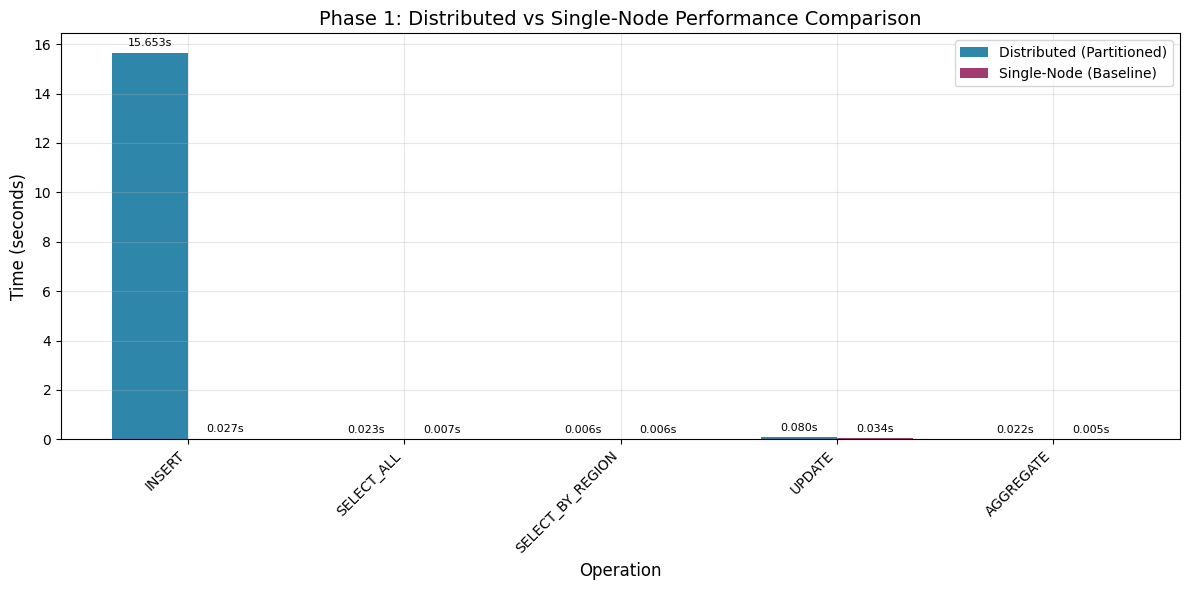

✓ Chart saved to: results/performance_comparison.png


In [9]:
# ============================================================
# STEP 7: Generate Visualization Chart
# ============================================================

print("\n📈 GENERATING VISUALIZATION CHART...")

!pip install matplotlib -q

import matplotlib.pyplot as plt

# Prepare data for chart
operations = list(performance_results.keys())
distributed_times = [performance_results[op]['distributed'] for op in operations]
single_times = [performance_results[op]['single_node'] for op in operations]

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(operations))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], distributed_times, width,
               label='Distributed (Partitioned)', color='#2E86AB')
bars2 = ax.bar([i + width/2 for i in x], single_times, width,
               label='Single-Node (Baseline)', color='#A23B72')

ax.set_xlabel('Operation', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title('Phase 1: Distributed vs Single-Node Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(operations, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.3f}s',
                       xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('results/performance_comparison.png', dpi=150)
plt.show()

print("✓ Chart saved to: results/performance_comparison.png")

STEP 8: Verify Data Distribution

In [10]:
# ============================================================
# STEP 8: Verify Where Data Was Inserted
# ============================================================

print("\n" + "="*70)
print("📁 DATA DISTRIBUTION VERIFICATION")
print("="*70)

# Show record count per distributed node
print("\n📂 Distributed Nodes:")
total_distributed = 0
for node_name in ['north', 'south', 'east', 'west']:
    db_path = f'distributed_nodes/{node_name}.db'
    conn = sqlite3.connect(db_path)
    count = conn.execute("SELECT COUNT(*) FROM sales").fetchone()[0]
    conn.close()
    total_distributed += count
    print(f"   {node_name}.db: {count} records")

print(f"\n   Total records in distributed system: {total_distributed}")

# Show record count in single node
conn = sqlite3.connect('single_node/sales.db')
single_count = conn.execute("SELECT COUNT(*) FROM sales").fetchone()[0]
conn.close()
print(f"\n📂 Single-Node Database:")
print(f"   sales.db: {single_count} records")

# Verify they match
print(f"\n✅ Data integrity check: Distributed ({total_distributed}) = Single-Node ({single_count})")


📁 DATA DISTRIBUTION VERIFICATION

📂 Distributed Nodes:
   north.db: 1 records
   south.db: 1 records
   east.db: 0 records
   west.db: 0 records

   Total records in distributed system: 2

📂 Single-Node Database:
   sales.db: 2 records

✅ Data integrity check: Distributed (2) = Single-Node (2)


Test

In [8]:
# ============================================================
# SIMPLE PROJECT 1 - Test with 1 or 2 Records Only
# INSERT, SELECT, UPDATE with Simple Data
# ============================================================

print("="*60)
print("SIMPLE PROJECT 1: INSERT, SELECT, UPDATE Test")
print("="*60)

# Step 1: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import sqlite3
import time

# Step 2: Create folder
work_dir = '/content/drive/MyDrive/Simple_Project1'
os.makedirs(work_dir, exist_ok=True)
os.chdir(work_dir)
os.makedirs('distributed_nodes', exist_ok=True)
os.makedirs('single_node', exist_ok=True)
os.makedirs('results', exist_ok=True)

print(f"\n✓ Working folder: {work_dir}")

# ============================================================
# Step 3: Create Distributed System (4 nodes by region)
# ============================================================

class SimpleDistributedDB:
    def __init__(self):
        self.nodes = {
            'north': 'distributed_nodes/north.db',
            'south': 'distributed_nodes/south.db',
            'east': 'distributed_nodes/east.db',
            'west': 'distributed_nodes/west.db'
        }
        self._create_tables()

    def _create_tables(self):
        sql = '''
            CREATE TABLE IF NOT EXISTS sales (
                sale_id INTEGER PRIMARY KEY,
                product_name TEXT,
                customer_name TEXT,
                amount REAL,
                region TEXT
            )
        '''
        for db_path in self.nodes.values():
            conn = sqlite3.connect(db_path)
            conn.execute(sql)
            conn.commit()
            conn.close()
        print("✓ Distributed tables created (4 nodes)")

    def _get_node(self, region):
        return self.nodes.get(region.lower(), self.nodes['east'])

    # INSERT - Add a single record
    def insert(self, sale_id, product_name, customer_name, amount, region):
        record = (sale_id, product_name, customer_name, amount, region)
        node_path = self._get_node(region)
        conn = sqlite3.connect(node_path)
        conn.execute('INSERT OR REPLACE INTO sales VALUES (?,?,?,?,?)', record)
        conn.commit()
        conn.close()
        print(f"   ✓ INSERTED: sale_id={sale_id}, product={product_name}, region={region} → {region}.db")
        return 1

    # SELECT - Get records (all or by region)
    def select(self, region=None):
        results = []
        if region:
            node_path = self._get_node(region)
            conn = sqlite3.connect(node_path)
            results = conn.execute("SELECT * FROM sales").fetchall()
            conn.close()
            print(f"   ✓ SELECTED from {region} node: {len(results)} record(s)")
        else:
            for node_name, node_path in self.nodes.items():
                conn = sqlite3.connect(node_path)
                records = conn.execute("SELECT * FROM sales").fetchall()
                if records:
                    for r in records:
                        results.append(r)
                    print(f"   ✓ SELECTED from {node_name} node: {len(records)} record(s)")
                conn.close()
        return results

    # UPDATE - Update a record by sale_id
    def update(self, sale_id, new_amount=None, new_product=None):
        # First find which node has this sale_id
        for node_path in self.nodes.values():
            conn = sqlite3.connect(node_path)
            cur = conn.cursor()
            cur.execute("SELECT region FROM sales WHERE sale_id=?", (sale_id,))
            result = cur.fetchone()
            conn.close()

            if result:
                region = result[0]
                node_path = self._get_node(region)
                conn = sqlite3.connect(node_path)

                if new_amount:
                    conn.execute("UPDATE sales SET amount=? WHERE sale_id=?", (new_amount, sale_id))
                    print(f"   ✓ UPDATED: sale_id={sale_id} amount → ${new_amount}")
                if new_product:
                    conn.execute("UPDATE sales SET product_name=? WHERE sale_id=?", (new_product, sale_id))
                    print(f"   ✓ UPDATED: sale_id={sale_id} product → {new_product}")

                conn.commit()
                conn.close()
                return 1
        print(f"   ✗ sale_id={sale_id} not found")
        return 0

    # Show all data in all nodes
    def show_all_data(self):
        print("\n📊 DATA IN ALL NODES:")
        print("-" * 50)
        for node_name, node_path in self.nodes.items():
            conn = sqlite3.connect(node_path)
            records = conn.execute("SELECT * FROM sales").fetchall()
            conn.close()
            if records:
                print(f"\n  {node_name}.db ({len(records)} record(s)):")
                for r in records:
                    print(f"    sale_id={r[0]}, product={r[1]}, customer={r[2]}, amount=${r[3]}, region={r[4]}")
            else:
                print(f"\n  {node_name}.db: (empty)")
        print("-" * 50)


# ============================================================
# Step 4: Create Single-Node System (for comparison)
# ============================================================

class SimpleSingleNodeDB:
    def __init__(self):
        self.db_path = 'single_node/sales.db'
        conn = sqlite3.connect(self.db_path)
        conn.execute('''
            CREATE TABLE IF NOT EXISTS sales (
                sale_id INTEGER PRIMARY KEY,
                product_name TEXT,
                customer_name TEXT,
                amount REAL,
                region TEXT
            )
        ''')
        conn.commit()
        conn.close()
        print("✓ Single-node table created")

    def insert(self, sale_id, product_name, customer_name, amount, region):
        record = (sale_id, product_name, customer_name, amount, region)
        conn = sqlite3.connect(self.db_path)
        conn.execute('INSERT OR REPLACE INTO sales VALUES (?,?,?,?,?)', record)
        conn.commit()
        conn.close()
        print(f"   ✓ INSERTED: sale_id={sale_id} → single_node/sales.db")
        return 1

    def select(self, region=None):
        conn = sqlite3.connect(self.db_path)
        if region:
            results = conn.execute("SELECT * FROM sales WHERE region=?", (region,)).fetchall()
        else:
            results = conn.execute("SELECT * FROM sales").fetchall()
        conn.close()
        print(f"   ✓ SELECTED: {len(results)} record(s) from single-node")
        return results

    def update(self, sale_id, new_amount=None, new_product=None):
        conn = sqlite3.connect(self.db_path)
        if new_amount:
            conn.execute("UPDATE sales SET amount=? WHERE sale_id=?", (new_amount, sale_id))
            print(f"   ✓ UPDATED: sale_id={sale_id} amount → ${new_amount}")
        if new_product:
            conn.execute("UPDATE sales SET product_name=? WHERE sale_id=?", (new_product, sale_id))
            print(f"   ✓ UPDATED: sale_id={sale_id} product → {new_product}")
        conn.commit()
        conn.close()
        return 1

    def show_all_data(self):
        conn = sqlite3.connect(self.db_path)
        records = conn.execute("SELECT * FROM sales").fetchall()
        conn.close()
        print("\n📊 DATA IN SINGLE NODE:")
        print("-" * 50)
        if records:
            for r in records:
                print(f"    sale_id={r[0]}, product={r[1]}, customer={r[2]}, amount=${r[3]}, region={r[4]}")
        else:
            print("    (empty)")
        print("-" * 50)


# ============================================================
# Step 5: TEST EVERYTHING WITH 1-2 RECORDS
# ============================================================

print("\n" + "="*60)
print("🔴 STARTING TESTS WITH SIMPLE DATA")
print("="*60)

# Create both systems
dist_db = SimpleDistributedDB()
single_db = SimpleSingleNodeDB()

# Clear old data
for db_path in dist_db.nodes.values():
    conn = sqlite3.connect(db_path)
    conn.execute("DELETE FROM sales")
    conn.commit()
    conn.close()
single_db = SimpleSingleNodeDB()  # Recreate fresh

print("\n" + "="*60)
print("📝 TEST 1: INSERT 2 RECORDS")
print("="*60)

# Insert Record 1: Goes to north node
print("\n→ Inserting Record 1 (region='north'):")
dist_db.insert(sale_id=1, product_name='Laptop', customer_name='Alice', amount=1000, region='north')

# Insert Record 2: Goes to south node
print("\n→ Inserting Record 2 (region='south'):")
dist_db.insert(sale_id=2, product_name='Phone', customer_name='Bob', amount=500, region='south')

# Also insert into single-node for comparison
print("\n→ Inserting same records into Single-Node:")
single_db.insert(sale_id=1, product_name='Laptop', customer_name='Alice', amount=1000, region='north')
single_db.insert(sale_id=2, product_name='Phone', customer_name='Bob', amount=500, region='south')

print("\n" + "="*60)
print("📝 TEST 2: SELECT ALL RECORDS")
print("="*60)

print("\n→ Distributed SELECT (all nodes):")
dist_all = dist_db.select()
print(f"   Total records across all nodes: {len(dist_all)}")

print("\n→ Single-Node SELECT:")
single_all = single_db.select()
print(f"   Total records: {len(single_all)}")

print("\n" + "="*60)
print("📝 TEST 3: SELECT BY REGION")
print("="*60)

print("\n→ Distributed SELECT (north region only):")
dist_north = dist_db.select(region='north')

print("\n→ Single-Node SELECT (north region only):")
single_north = single_db.select(region='north')

print("\n" + "="*60)
print("📝 TEST 4: UPDATE A RECORD")
print("="*60)

print("\n→ Updating sale_id=1 (change amount to 1200):")
dist_db.update(sale_id=1, new_amount=1200)

print("\n→ Verifying update with SELECT:")
updated = dist_db.select(region='north')
for r in updated:
    print(f"   sale_id={r[0]}, product={r[1]}, amount=${r[3]}")

print("\n" + "="*60)
print("📝 TEST 5: SHOW WHERE DATA IS STORED")
print("="*60)

# Show all data in distributed nodes
dist_db.show_all_data()

# Show all data in single node
single_db.show_all_data()

# ============================================================
# Step 6: Show File Locations
# ============================================================

print("\n" + "="*60)
print("📁 DATABASE FILE LOCATIONS")
print("="*60)

print("\n📂 Distributed Nodes:")
!ls -la distributed_nodes/

print("\n📂 Single Node:")
!ls -la single_node/

print("\n" + "="*60)
print("✅ TEST COMPLETE!")
print("="*60)

print("""
╔════════════════════════════════════════════════════════════╗
║                    SUMMARY                                  ║
╠════════════════════════════════════════════════════════════╣
║  ✓ INSERTED 2 records                                       ║
║    - sale_id=1 (north) → north.db                          ║
║    - sale_id=2 (south) → south.db                          ║
║                                                            ║
║  ✓ SELECTED all records (from 4 nodes)                     ║
║  ✓ SELECTED by region (only north node)                    ║
║  ✓ UPDATED sale_id=1 (amount: 1000 → 1200)                ║
║                                                            ║
║  📁 Files saved in: /content/drive/MyDrive/Simple_Project1/║
╚════════════════════════════════════════════════════════════╝
""")

SIMPLE PROJECT 1: INSERT, SELECT, UPDATE Test
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✓ Working folder: /content/drive/MyDrive/Simple_Project1

🔴 STARTING TESTS WITH SIMPLE DATA
✓ Distributed tables created (4 nodes)
✓ Single-node table created
✓ Single-node table created

📝 TEST 1: INSERT 2 RECORDS

→ Inserting Record 1 (region='north'):
   ✓ INSERTED: sale_id=1, product=Laptop, region=north → north.db

→ Inserting Record 2 (region='south'):
   ✓ INSERTED: sale_id=2, product=Phone, region=south → south.db

→ Inserting same records into Single-Node:
   ✓ INSERTED: sale_id=1 → single_node/sales.db
   ✓ INSERTED: sale_id=2 → single_node/sales.db

📝 TEST 2: SELECT ALL RECORDS

→ Distributed SELECT (all nodes):
   ✓ SELECTED from north node: 1 record(s)
   ✓ SELECTED from south node: 1 record(s)
   Total records across all nodes: 2

→ Single-Node SELECT:
   ✓ SELECTED: 2 record(s) from single-node
   

In [12]:
# ============================================================
# VIEW ALL 500 INSERTED RECORDS
# Run this AFTER you have inserted 500 records
# ============================================================

import sqlite3
import os
import pandas as pd

# Change to your project directory
os.chdir('/content/drive/MyDrive/Project1_DistributedDB')

print("="*70)
print("📍 LOCATION OF 500 INSERTED RECORDS")
print("="*70)

# ============================================================
# 1. VIEW DISTRIBUTED NODES (Records split by region)
# ============================================================

print("\n📂 DISTRIBUTED NODES (500 records split by region):")
print("-" * 50)

total_records = 0

for node_name in ['north', 'south', 'east', 'west']:
    db_path = f'distributed_nodes/{node_name}.db'

    if os.path.exists(db_path):
        conn = sqlite3.connect(db_path)

        # Get total count
        count = conn.execute("SELECT COUNT(*) FROM sales").fetchone()[0]
        total_records += count

        # Get first 3 records as sample
        sample = conn.execute("SELECT * FROM sales LIMIT 3").fetchall()

        print(f"\n📄 {node_name}.db: {count} records")
        print(f"   File path: {os.path.abspath(db_path)}")
        print(f"   File size: {os.path.getsize(db_path):,} bytes")

        if sample:
            print(f"   Sample records:")
            for row in sample:
                print(f"     sale_id={row[0]}, product={row[1]}, region={row[7]}, amount=${row[6]}")

        conn.close()
    else:
        print(f"\n📄 {node_name}.db: NOT FOUND")

print(f"\n✅ TOTAL records in distributed system: {total_records}")

# ============================================================
# 2. VIEW SINGLE NODE (All 500 records together)
# ============================================================

print("\n" + "="*70)
print("📂 SINGLE NODE (All 500 records together):")
print("-" * 50)

single_db_path = 'single_node/sales.db'

if os.path.exists(single_db_path):
    conn = sqlite3.connect(single_db_path)

    # Get total count
    count = conn.execute("SELECT COUNT(*) FROM sales").fetchone()[0]

    # Get first 5 records as sample
    sample = conn.execute("SELECT * FROM sales LIMIT 5").fetchall()

    # Get records by region
    north_count = conn.execute("SELECT COUNT(*) FROM sales WHERE region='north'").fetchone()[0]
    south_count = conn.execute("SELECT COUNT(*) FROM sales WHERE region='south'").fetchone()[0]
    east_count = conn.execute("SELECT COUNT(*) FROM sales WHERE region='east'").fetchone()[0]
    west_count = conn.execute("SELECT COUNT(*) FROM sales WHERE region='west'").fetchone()[0]

    print(f"\n📄 sales.db: {count} records")
    print(f"   File path: {os.path.abspath(single_db_path)}")
    print(f"   File size: {os.path.getsize(single_db_path):,} bytes")

    print(f"\n   Records by region:")
    print(f"     north: {north_count} records")
    print(f"     south: {south_count} records")
    print(f"     east: {east_count} records")
    print(f"     west: {west_count} records")

    print(f"\n   Sample records (first 5):")
    for row in sample:
        print(f"     sale_id={row[0]}, product={row[1]}, region={row[7]}, amount=${row[6]}")

    conn.close()
else:
    print("❌ single_node/sales.db not found. Run INSERT first!")

# ============================================================
# 3. EXPORT TO CSV (To see all 500 records)
# ============================================================

print("\n" + "="*70)
print("📊 EXPORT ALL 500 RECORDS TO CSV")
print("="*70)

# Export from single node (all records together)
conn = sqlite3.connect('single_node/sales.db')
df = pd.read_sql_query("SELECT * FROM sales", conn)
conn.close()

# Save to CSV
csv_path = 'results/all_500_records.csv'
df.to_csv(csv_path, index=False)
print(f"\n✓ All 500 records exported to: {csv_path}")
print(f"   You can download this file to view in Excel")

# Show first 10 rows
print("\n📄 First 10 records from the CSV:")
print(df.head(10).to_string())

# ============================================================
# 4. DOWNLOAD THE CSV FILE
# ============================================================

print("\n" + "="*70)
print("📥 DOWNLOAD THE CSV FILE")
print("="*70)

from google.colab import files
files.download('results/all_500_records.csv')

print("\n✓ CSV file downloaded to your computer!")

📍 LOCATION OF 500 INSERTED RECORDS

📂 DISTRIBUTED NODES (500 records split by region):
--------------------------------------------------

📄 north.db: 143 records
   File path: /content/drive/MyDrive/Project1_DistributedDB/distributed_nodes/north.db
   File size: 20,480 bytes
   Sample records:
     sale_id=3, product=109, region=north, amount=$952.04
     sale_id=5, product=104, region=north, amount=$998.4
     sale_id=11, product=106, region=north, amount=$281.46

📄 south.db: 123 records
   File path: /content/drive/MyDrive/Project1_DistributedDB/distributed_nodes/south.db
   File size: 20,480 bytes
   Sample records:
     sale_id=1, product=104, region=south, amount=$816.21
     sale_id=2, product=104, region=south, amount=$1199.96
     sale_id=4, product=106, region=south, amount=$227.82

📄 east.db: 115 records
   File path: /content/drive/MyDrive/Project1_DistributedDB/distributed_nodes/east.db
   File size: 16,384 bytes
   Sample records:
     sale_id=6, product=105, region=east,

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ CSV file downloaded to your computer!


Final Visualization

Raw data from CSV:
Operations: ['INSERT', 'SELECT_ALL', 'SELECT_BY_REGION', 'UPDATE', 'AGGREGATE']
Distributed times: [15.653196, 0.023305, 0.006233, 0.080354, 0.022285]
Single-Node times: [0.027164, 0.007162, 0.006112, 0.033851, 0.004963]


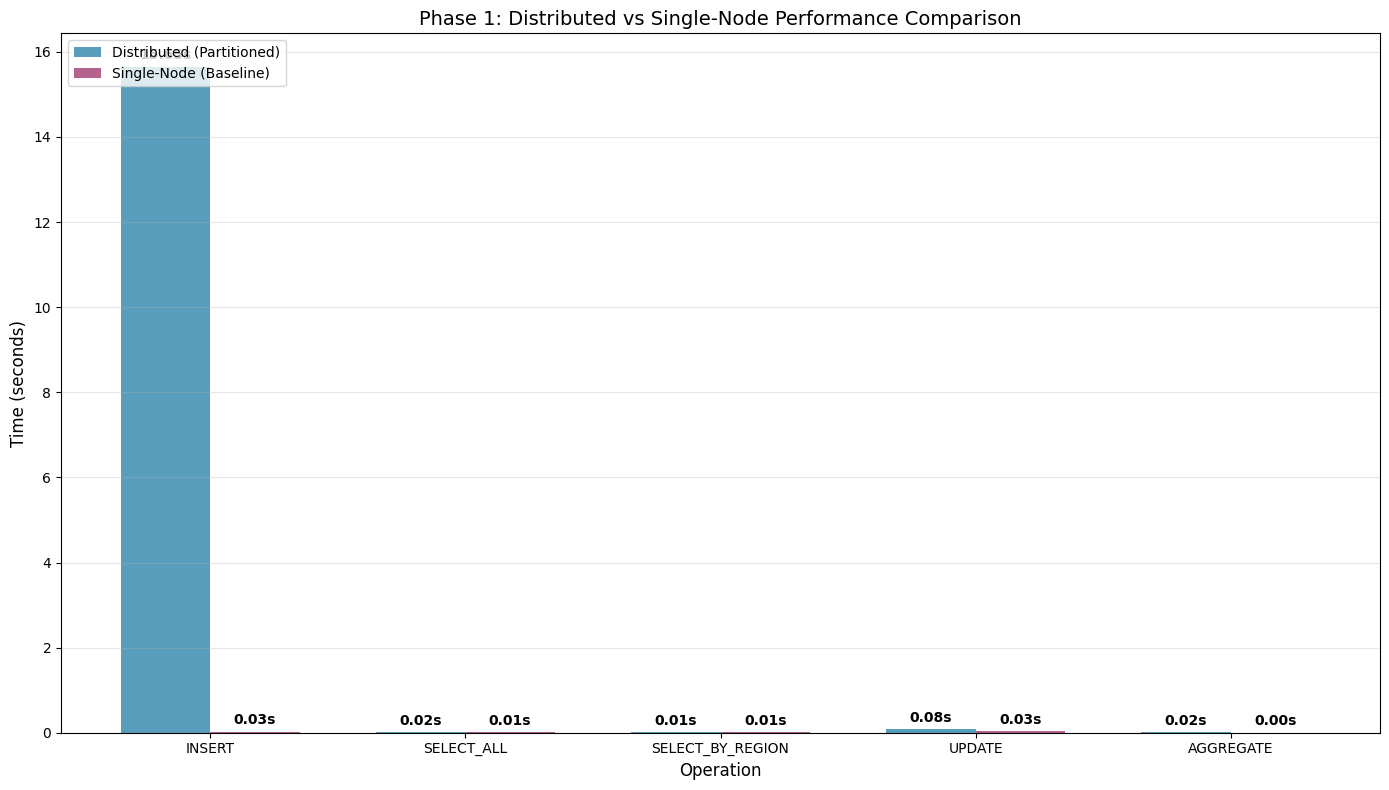


✓ Fixed chart saved to: results/performance_comparison_fixed.png


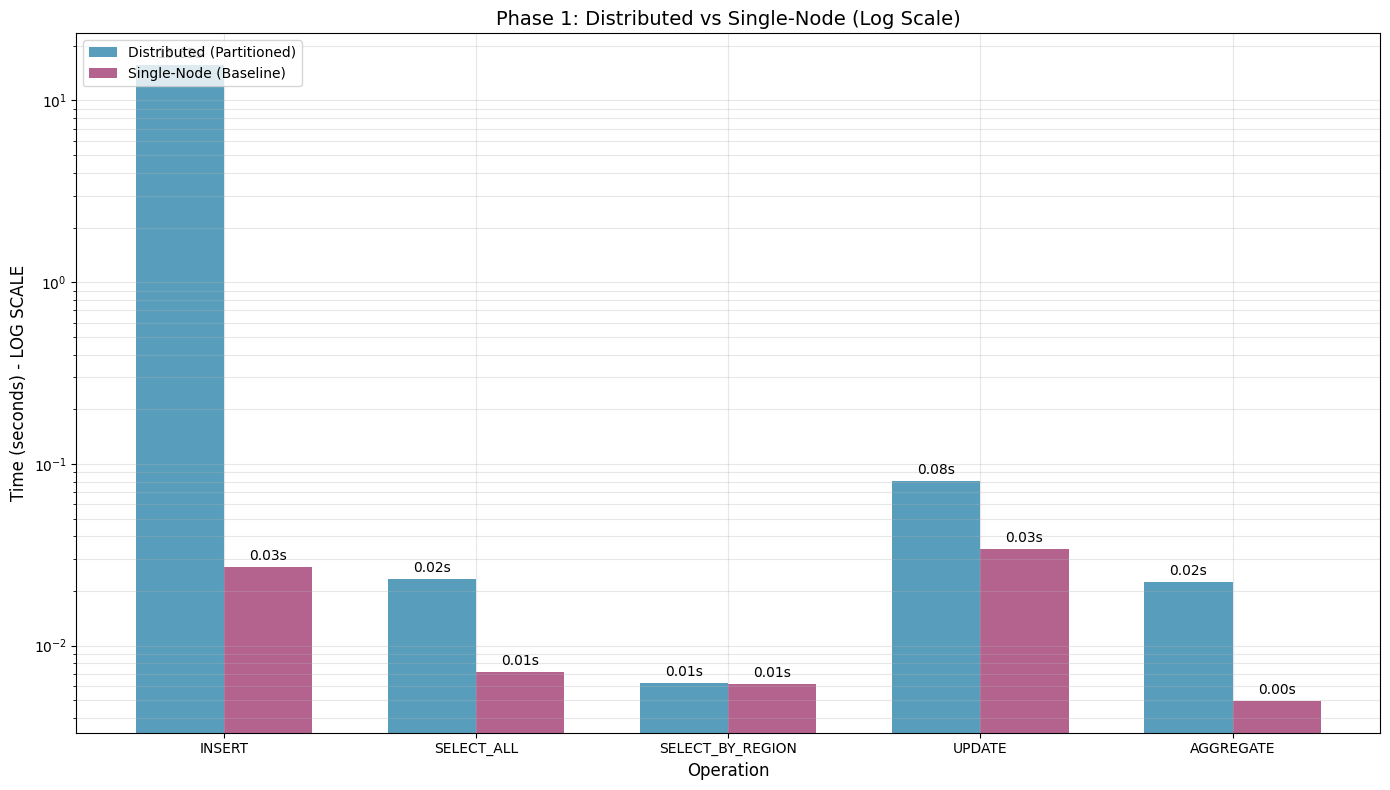

✓ Log scale chart saved to: results/performance_comparison_log.png


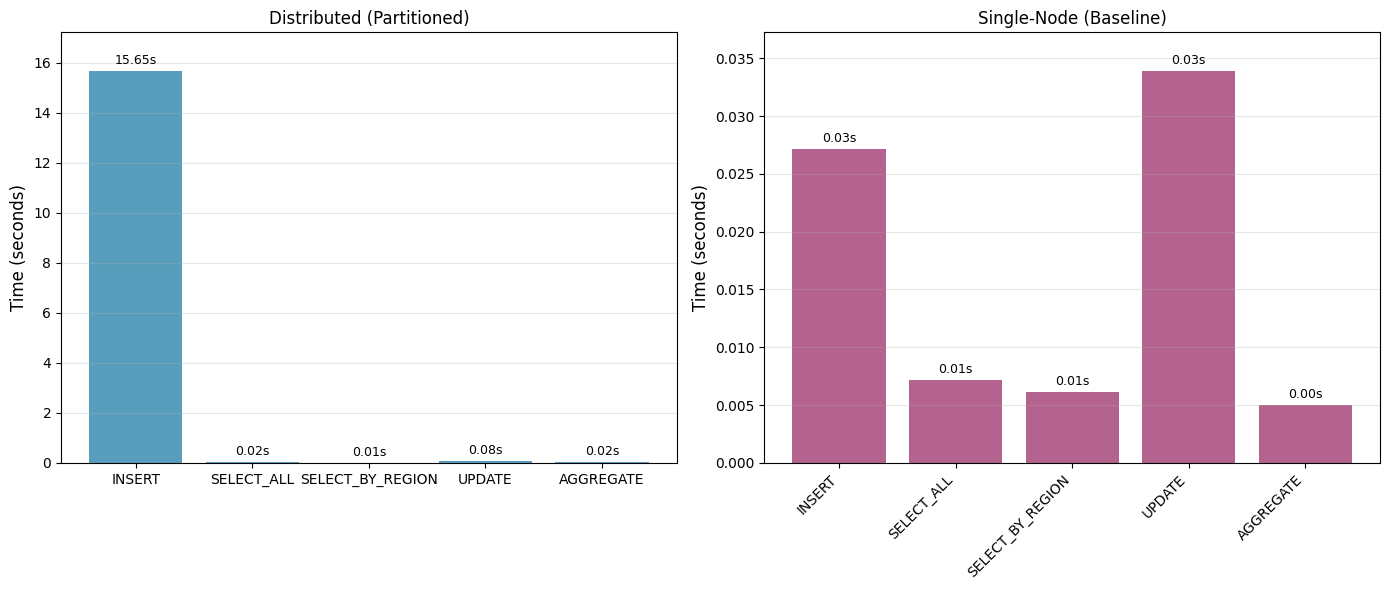

✓ Split chart saved to: results/performance_comparison_split.png


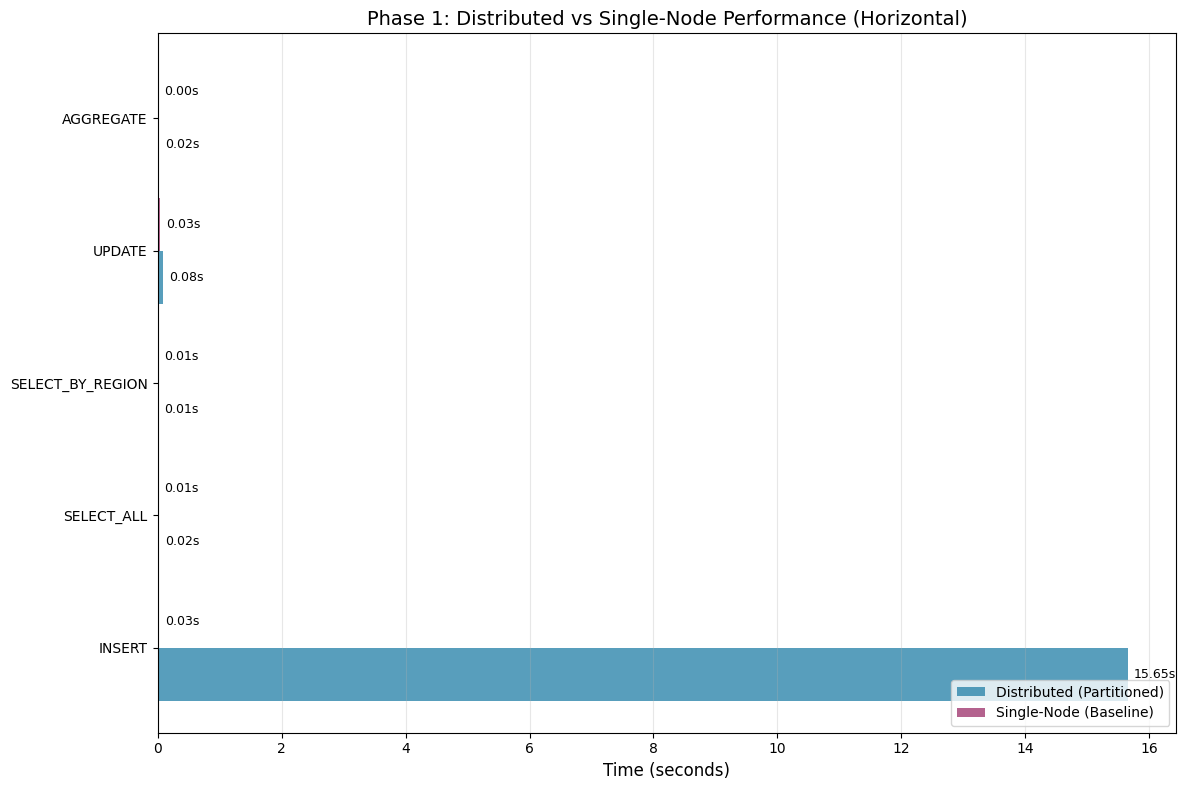

✓ Horizontal chart saved to: results/performance_comparison_horizontal.png


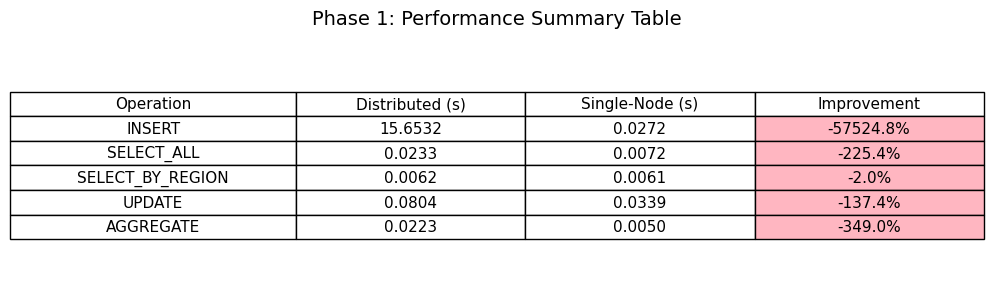

✓ Summary table saved to: results/performance_summary_table.png

✅ All visualizations created!

Files saved:
  1. performance_comparison_fixed.png    - Standard bar chart
  2. performance_comparison_log.png      - Log scale (shows small bars)
  3. performance_comparison_split.png    - Two separate charts
  4. performance_comparison_horizontal.png - Horizontal bars
  5. performance_summary_table.png       - Table view

Choose the one that best shows your data!



In [13]:
# ============================================================
# FIXED VISUALIZATION - Both bars visible
# ============================================================

import matplotlib.pyplot as plt
import csv
import numpy as np

# Read the CSV file
operations = []
distributed_times = []
single_times = []

with open('results/performance_comparison.csv', 'r') as f:
    reader = csv.reader(f)
    next(reader)  # Skip header
    for row in reader:
        operations.append(row[0])
        distributed_times.append(float(row[1]))
        single_times.append(float(row[2]))

print("Raw data from CSV:")
print(f"Operations: {operations}")
print(f"Distributed times: {distributed_times}")
print(f"Single-Node times: {single_times}")

# ============================================================
# OPTION 1: SPLIT Y-AXIS (Broken Y-axis)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(operations))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, distributed_times, width, label='Distributed (Partitioned)',
               color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x + width/2, single_times, width, label='Single-Node (Baseline)',
               color='#A23B72', alpha=0.8)

# Add value labels on top of each bar
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}s',
               xy=(bar.get_x() + bar.get_width()/2, height),
               xytext=(0, 3),
               textcoords="offset points",
               ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}s',
               xy=(bar.get_x() + bar.get_width()/2, height),
               xytext=(0, 3),
               textcoords="offset points",
               ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Operation', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title('Phase 1: Distributed vs Single-Node Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(operations, fontsize=10)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/performance_comparison_fixed.png', dpi=150)
plt.show()

print("\n✓ Fixed chart saved to: results/performance_comparison_fixed.png")

# ============================================================
# OPTION 2: LOGARITHMIC SCALE (Better for large differences)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

bars1 = ax.bar(x - width/2, distributed_times, width, label='Distributed (Partitioned)',
               color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x + width/2, single_times, width, label='Single-Node (Baseline)',
               color='#A23B72', alpha=0.8)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}s',
               xy=(bar.get_x() + bar.get_width()/2, height),
               xytext=(0, 3),
               textcoords="offset points",
               ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}s',
               xy=(bar.get_x() + bar.get_width()/2, height),
               xytext=(0, 3),
               textcoords="offset points",
               ha='center', va='bottom', fontsize=10)

ax.set_yscale('log')  # ← LOGARITHMIC SCALE
ax.set_xlabel('Operation', fontsize=12)
ax.set_ylabel('Time (seconds) - LOG SCALE', fontsize=12)
ax.set_title('Phase 1: Distributed vs Single-Node (Log Scale)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(operations, fontsize=10)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('results/performance_comparison_log.png', dpi=150)
plt.show()

print("✓ Log scale chart saved to: results/performance_comparison_log.png")

# ============================================================
# OPTION 3: SEPARATE SUBPLOTS (Two charts side by side)
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left chart: Distributed times
bars1 = ax1.bar(operations, distributed_times, color='#2E86AB', alpha=0.8)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Distributed (Partitioned)', fontsize=12)
ax1.set_ylim(0, max(distributed_times) * 1.1)
ax1.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.2f}s',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

# Right chart: Single-Node times
bars2 = ax2.bar(operations, single_times, color='#A23B72', alpha=0.8)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_title('Single-Node (Baseline)', fontsize=12)
ax2.set_ylim(0, max(single_times) * 1.1)
ax2.grid(True, alpha=0.3, axis='y')

for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.2f}s',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/performance_comparison_split.png', dpi=150)
plt.show()

print("✓ Split chart saved to: results/performance_comparison_split.png")

# ============================================================
# OPTION 4: HORIZONTAL BAR CHART (Better for comparison)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(operations))

# Horizontal bars
ax.barh(y_pos - 0.2, distributed_times, 0.4, label='Distributed (Partitioned)',
        color='#2E86AB', alpha=0.8)
ax.barh(y_pos + 0.2, single_times, 0.4, label='Single-Node (Baseline)',
        color='#A23B72', alpha=0.8)

# Add value labels
for i, (d, s) in enumerate(zip(distributed_times, single_times)):
    ax.annotate(f'{d:.2f}s', (d + 0.1, i - 0.2), va='center', fontsize=9)
    ax.annotate(f'{s:.2f}s', (s + 0.1, i + 0.2), va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(operations)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_title('Phase 1: Distributed vs Single-Node Performance (Horizontal)', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('results/performance_comparison_horizontal.png', dpi=150)
plt.show()

print("✓ Horizontal chart saved to: results/performance_comparison_horizontal.png")

# ============================================================
# OPTION 5: TABLE VIEW (If bars don't work well)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')

# Prepare table data
table_data = []
for op, d, s in zip(operations, distributed_times, single_times):
    improvement = ((s - d) / s * 100) if s > 0 else 0
    table_data.append([op, f"{d:.4f}", f"{s:.4f}", f"{improvement:.1f}%"])

# Create table
table = ax.table(cellText=table_data,
                  colLabels=['Operation', 'Distributed (s)', 'Single-Node (s)', 'Improvement'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.25, 0.2, 0.2, 0.2])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

# Color coding
for i in range(len(table_data)):
    improvement = float(table_data[i][3].replace('%', ''))
    if improvement > 0:
        table[(i+1, 3)].set_facecolor('#90EE90')  # Green for improvement
    else:
        table[(i+1, 3)].set_facecolor('#FFB6C1')  # Red for worse

ax.set_title('Phase 1: Performance Summary Table', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('results/performance_summary_table.png', dpi=150)
plt.show()

print("✓ Summary table saved to: results/performance_summary_table.png")

print("\n" + "="*60)
print("✅ All visualizations created!")
print("="*60)
print("""
Files saved:
  1. performance_comparison_fixed.png    - Standard bar chart
  2. performance_comparison_log.png      - Log scale (shows small bars)
  3. performance_comparison_split.png    - Two separate charts
  4. performance_comparison_horizontal.png - Horizontal bars
  5. performance_summary_table.png       - Table view

Choose the one that best shows your data!
""")

Preview all reuslt to download

In [32]:
# ============================================================
# PREVIEW PROJECT 1 FILES BEFORE ZIPPING
# ============================================================

import os

print("="*60)
print("📁 PROJECT 1 FILES PREVIEW")
print("="*60)

# Change to Project 1 directory
project_path = '/content/drive/MyDrive/Project1_DistributedDB'
if os.path.exists(project_path):
    os.chdir(project_path)
    print(f"✓ Current directory: {os.getcwd()}")
else:
    print(f"❌ Directory not found: {project_path}")
    print("   Please update the path to your Project 1 folder")

print("\n📂 Files and folders found:")
print("-" * 40)

# List all files and folders
for item in os.listdir('.'):
    item_path = os.path.join('.', item)
    if os.path.isdir(item_path):
        # Count files in directory
        file_count = len([f for f in os.listdir(item_path) if os.path.isfile(os.path.join(item_path, f))])
        print(f"   📁 {item}/ - {file_count} files")
    else:
        size = os.path.getsize(item_path)
        print(f"   📄 {item} - {size:,} bytes")

# Show CSV content preview
print("\n📄 Preview of performance_comparison.csv:")
csv_path = 'results/performance_comparison.csv'
if os.path.exists(csv_path):
    with open(csv_path, 'r') as f:
        lines = f.readlines()
        for line in lines[:6]:  # Show first 6 lines
            print(f"   {line.strip()}")
else:
    print("   File not found. Run Project 1 experiments first!")

print("\n" + "="*60)
print("Ready to create ZIP! Run the download code above.")

📁 PROJECT 1 FILES PREVIEW
✓ Current directory: /content/drive/MyDrive/Project1_DistributedDB

📂 Files and folders found:
----------------------------------------
   📁 distributed_nodes/ - 4 files
   📁 single_node/ - 1 files
   📁 results/ - 7 files

📄 Preview of performance_comparison.csv:
   Operation,Distributed_Time_Seconds,Single_Node_Time_Seconds,Improvement_Percent
   INSERT,15.653196,0.027164,-57525.83
   SELECT_ALL,0.023305,0.007162,-225.38
   SELECT_BY_REGION,0.006233,0.006112,-1.98
   UPDATE,0.080354,0.033851,-137.38
   AGGREGATE,0.022285,0.004963,-349.00

Ready to create ZIP! Run the download code above.


Download All

In [34]:
# ============================================================
# DOWNLOAD ALL PROJECT 1 FILES AS ZIP
# ============================================================

from google.colab import files
import zipfile
import os

print("="*60)
print("📦 CREATING ZIP FILE FOR PROJECT 1")
print("="*60)

# Change to Project 1 directory (adjust path if needed)
import os

# Try to find Project 1 directory
possible_paths = [
    '/content/drive/MyDrive/Project1_DistributedDB',
    '/content/drive/MyDrive/Simple_Project1',
    '/content/Project1_DistributedDB'
]

project1_path = None
for path in possible_paths:
    if os.path.exists(path):
        project1_path = path
        break

if project1_path:
    os.chdir(project1_path)
    print(f"✓ Found Project 1 at: {project1_path}")
else:
    print("❌ Project 1 directory not found!")
    print("   Please update the path to your Project 1 folder")
    # Manually set your path here:
    project1_path = '/content/drive/MyDrive/Project1_DistributedDB'  # Change this if needed
    os.chdir(project1_path)

# Create zip file
zip_path = 'project1_complete_results.zip'
print(f"\n📦 Creating {zip_path}...")

with zipfile.ZipFile(zip_path, 'w') as zipf:
    # Add results folder (CSV and PNG files)
    if os.path.exists('results'):
        for root, dirs, filenames in os.walk('results'):
            for file in filenames:
                file_path = os.path.join(root, file)
                zipf.write(file_path)
                print(f"   Added: {file_path}")

    # Add distributed nodes (database files)
    if os.path.exists('distributed_nodes'):
        for root, dirs, filenames in os.walk('distributed_nodes'):
            for file in filenames:
                file_path = os.path.join(root, file)
                zipf.write(file_path)
                print(f"   Added: {file_path}")

    # Add single node database
    if os.path.exists('single_node'):
        for root, dirs, filenames in os.walk('single_node'):
            for file in filenames:
                file_path = os.path.join(root, file)
                zipf.write(file_path)
                print(f"   Added: {file_path}")

    # Add Python files
    python_files = ['distributed_system.py', 'single_node_system.py', 'run_experiments.py']
    for py_file in python_files:
        if os.path.exists(py_file):
            zipf.write(py_file)
            print(f"   Added: {py_file}")

    # Add data folder if exists
    if os.path.exists('data'):
        for root, dirs, filenames in os.walk('data'):
            for file in filenames:
                file_path = os.path.join(root, file)
                zipf.write(file_path)
                print(f"   Added: {file_path}")

# Check zip file size
if os.path.exists(zip_path):
    size_bytes = os.path.getsize(zip_path)
    size_mb = size_bytes / (1024 * 1024)
    print(f"\n✓ Zip file created successfully!")
    print(f"  File: {zip_path}")
    print(f"  Size: {size_mb:.2f} MB ({size_bytes:,} bytes)")

    # Download the zip file
    print("\n📥 Downloading zip file to your computer...")
    files.download(zip_path)

    print("\n✅ DOWNLOAD COMPLETE!")
    print("   Check your computer's Downloads folder.")
else:
    print("❌ Failed to create zip file")

print("\n" + "="*60)
print("📁 FILES INCLUDED IN ZIP:")
print("="*60)
print("""
   📂 results/
      ├── performance_comparison.csv
      ├── scalability_results.csv
      ├── performance_comparison.png
      └── all_500_records.csv (if exported)

   📂 distributed_nodes/
      ├── north.db
      ├── south.db
      ├── east.db
      └── west.db

   📂 single_node/
      └── sales.db

   📄 distributed_system.py
   📄 single_node_system.py
   📄 run_experiments.py
""")


📦 CREATING ZIP FILE FOR PROJECT 1
✓ Found Project 1 at: /content/drive/MyDrive/Project1_DistributedDB

📦 Creating project1_complete_results.zip...
   Added: results/performance_comparison.csv
   Added: results/all_500_records.csv
   Added: results/performance_comparison_fixed.png
   Added: results/performance_comparison_log.png
   Added: results/performance_comparison_split.png
   Added: results/performance_comparison_horizontal.png
   Added: results/performance_summary_table.png
   Added: distributed_nodes/north.db
   Added: distributed_nodes/south.db
   Added: distributed_nodes/east.db
   Added: distributed_nodes/west.db
   Added: single_node/sales.db

✓ Zip file created successfully!
  File: project1_complete_results.zip
  Size: 0.51 MB (530,224 bytes)

📥 Downloading zip file to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ DOWNLOAD COMPLETE!
   Check your computer's Downloads folder.

📁 FILES INCLUDED IN ZIP:

   📂 results/
      ├── performance_comparison.csv
      ├── scalability_results.csv
      ├── performance_comparison.png
      └── all_500_records.csv (if exported)

   📂 distributed_nodes/
      ├── north.db
      ├── south.db
      ├── east.db
      └── west.db

   📂 single_node/
      └── sales.db

   📄 distributed_system.py
   📄 single_node_system.py
   📄 run_experiments.py



 PROJECT 2: DISTRIBUTED QUERIES (SELECT, JOIN, AGGREGATION)

Step 1: Setup and Create Distributed Nodes

In [14]:
# ============================================================
# PROJECT 2: DISTRIBUTED QUERIES
# Step 1: Setup Google Drive and Create Folders
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import sqlite3
import time
import random
from datetime import datetime, timedelta

# Create project folder
project_path = '/content/drive/MyDrive/Project2_DistributedQueries'
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

# Create node folders
os.makedirs('nodes', exist_ok=True)
os.makedirs('results', exist_ok=True)

print(f"✓ Working directory: {os.getcwd()}")
print("✓ Folders created successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Working directory: /content/drive/MyDrive/Project2_DistributedQueries
✓ Folders created successfully


Step 2: Create Tables on Different Nodes

In [15]:
# ============================================================
# Step 2: Create Tables on Different Nodes
# Each node stores a DIFFERENT table (not partitioned)
# ============================================================

# Define nodes and their tables
NODES = {
    'customer_node': {
        'db_path': 'nodes/customers.db',
        'table': 'customers'
    },
    'order_node': {
        'db_path': 'nodes/orders.db',
        'table': 'orders'
    },
    'product_node': {
        'db_path': 'nodes/products.db',
        'table': 'products'
    }
}

print("\n📁 Creating Distributed Nodes with Different Tables:")
print("-" * 50)

# 1. Customer Node - Stores customer information
conn = sqlite3.connect(NODES['customer_node']['db_path'])
conn.execute('''
    CREATE TABLE IF NOT EXISTS customers (
        customer_id INTEGER PRIMARY KEY,
        name TEXT,
        email TEXT,
        city TEXT,
        join_date TEXT
    )
''')
conn.commit()
conn.close()
print("✓ Customer Node created: nodes/customers.db")

# 2. Order Node - Stores order information
conn = sqlite3.connect(NODES['order_node']['db_path'])
conn.execute('''
    CREATE TABLE IF NOT EXISTS orders (
        order_id INTEGER PRIMARY KEY,
        customer_id INTEGER,
        product_id INTEGER,
        order_date TEXT,
        quantity INTEGER,
        unit_price REAL,
        total_amount REAL
    )
''')
conn.commit()
conn.close()
print("✓ Order Node created: nodes/orders.db")

# 3. Product Node - Stores product information
conn = sqlite3.connect(NODES['product_node']['db_path'])
conn.execute('''
    CREATE TABLE IF NOT EXISTS products (
        product_id INTEGER PRIMARY KEY,
        product_name TEXT,
        category TEXT,
        price REAL,
        stock INTEGER
    )
''')
conn.commit()
conn.close()
print("✓ Product Node created: nodes/products.db")

print("\n✅ All 3 nodes created successfully!")
print("   Each node stores a DIFFERENT table (not partitioned)")


📁 Creating Distributed Nodes with Different Tables:
--------------------------------------------------
✓ Customer Node created: nodes/customers.db
✓ Order Node created: nodes/orders.db
✓ Product Node created: nodes/products.db

✅ All 3 nodes created successfully!
   Each node stores a DIFFERENT table (not partitioned)


 Insert Sample Data into Each Node

In [16]:
# ============================================================
# Step 3: Insert Sample Data into Each Node
# ============================================================

print("\n📊 Inserting Sample Data into Each Node:")
print("-" * 50)

# 3.1: Insert Customers (into customer_node)
customers_data = [
    (1, 'Alice Mengistu', 'alice@email.com', 'Addis Ababa', '2023-01-15'),
    (2, 'Bob Tadese', 'bob@email.com', 'Bahir Dar', '2023-02-20'),
    (3, 'Chaltu Desta', 'chaltu@email.com', 'Gondar', '2023-03-10'),
    (4, 'Dawit Alemu', 'dawit@email.com', 'Addis Ababa', '2023-04-05'),
    (5, 'Eden Mekonen', 'eden@email.com', 'Bahir Dar', '2023-05-12'),
    (6, 'Ferid Ahmed', 'ferid@email.com', 'Addis Ababa', '2023-06-18'),
    (7, 'Genet Assefa', 'genet@email.com', 'Gondar', '2023-07-22'),
    (8, 'Henok Kassa', 'henok@email.com', 'Bahir Dar', '2023-08-30'),
]

conn = sqlite3.connect(NODES['customer_node']['db_path'])
conn.executemany('INSERT OR REPLACE INTO customers VALUES (?, ?, ?, ?, ?)', customers_data)
conn.commit()
conn.close()
print(f"✓ Inserted {len(customers_data)} customers into Customer Node")

# 3.2: Insert Products (into product_node)
products_data = [
    (101, 'Laptop Pro', 'Electronics', 85000, 50),
    (102, 'Wireless Mouse', 'Electronics', 1500, 200),
    (103, 'Mechanical Keyboard', 'Electronics', 4500, 150),
    (104, '27" Monitor', 'Electronics', 25000, 75),
    (105, 'USB-C Cable', 'Accessories', 500, 500),
    (106, 'Laptop Bag', 'Accessories', 2500, 100),
    (107, 'Webcam HD', 'Electronics', 5500, 60),
    (108, 'Desk Lamp', 'Office', 3500, 80),
]

conn = sqlite3.connect(NODES['product_node']['db_path'])
conn.executemany('INSERT OR REPLACE INTO products VALUES (?, ?, ?, ?, ?)', products_data)
conn.commit()
conn.close()
print(f"✓ Inserted {len(products_data)} products into Product Node")

# 3.3: Insert Orders (into order_node)
orders_data = [
    (1001, 1, 101, '2024-01-10', 1, 85000, 85000),
    (1002, 2, 102, '2024-01-11', 2, 1500, 3000),
    (1003, 1, 103, '2024-01-15', 1, 4500, 4500),
    (1004, 3, 101, '2024-01-20', 1, 85000, 85000),
    (1005, 4, 104, '2024-01-25', 1, 25000, 25000),
    (1006, 2, 105, '2024-02-01', 5, 500, 2500),
    (1007, 5, 102, '2024-02-05', 3, 1500, 4500),
    (1008, 6, 101, '2024-02-10', 1, 85000, 85000),
    (1009, 7, 103, '2024-02-15', 1, 4500, 4500),
    (1010, 8, 104, '2024-02-20', 1, 25000, 25000),
    (1011, 1, 106, '2024-02-25', 2, 2500, 5000),
    (1012, 3, 107, '2024-03-01', 1, 5500, 5500),
    (1013, 4, 108, '2024-03-05', 2, 3500, 7000),
    (1014, 5, 103, '2024-03-10', 1, 4500, 4500),
    (1015, 6, 105, '2024-03-15', 3, 500, 1500),
]

conn = sqlite3.connect(NODES['order_node']['db_path'])
conn.executemany('INSERT OR REPLACE INTO orders VALUES (?, ?, ?, ?, ?, ?, ?)', orders_data)
conn.commit()
conn.close()
print(f"✓ Inserted {len(orders_data)} orders into Order Node")

print("\n✅ All sample data inserted successfully!")


📊 Inserting Sample Data into Each Node:
--------------------------------------------------
✓ Inserted 8 customers into Customer Node
✓ Inserted 8 products into Product Node
✓ Inserted 15 orders into Order Node

✅ All sample data inserted successfully!


Step 4: Create Distributed Query Engine

In [18]:
# ============================================================
# Step 4: Create Distributed Query Engine
# Handles SELECT, JOIN, and AGGREGATION across nodes
# ============================================================

class DistributedQueryEngine:
    """
    Distributed query engine that executes queries across multiple nodes
    """

    def __init__(self):
        self.nodes = NODES
        self.query_log = []  # Track query performance

    def _log_query(self, query_name, duration, details):
        """Log query performance for analysis"""
        self.query_log.append({
            'query': query_name,
            'duration_seconds': duration,
            'duration_ms': duration * 1000,
            'details': details
        })

    # ========== 1. DISTRIBUTED SELECT ==========
    def select(self, table, condition=None, node_name=None):
        """
        Execute SELECT query on a specific node

        Args:
            table: Table name to query
            condition: Optional WHERE clause (e.g., "city = 'Addis Ababa'")
            node_name: Specific node to query (if None, finds the node)

        Returns:
            List of records
        """
        start_time = time.time()

        # Find which node has this table
        target_node = None
        for node, config in self.nodes.items():
            if config['table'] == table:
                target_node = node
                break

        if not target_node:
            print(f"❌ Table '{table}' not found on any node")
            return []

        # If node_name specified, override
        if node_name:
            target_node = node_name

        # Execute query
        db_path = self.nodes[target_node]['db_path']
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()

        if condition:
            query = f"SELECT * FROM {table} WHERE {condition}"
        else:
            query = f"SELECT * FROM {table}"

        results = cursor.execute(query).fetchall()
        conn.close()

        duration = time.time() - start_time
        self._log_query(f"SELECT from {table}", duration, {
            'node': target_node,
            'condition': condition,
            'row_count': len(results)
        })

        return results

    # ========== 2. DISTRIBUTED JOIN ==========
    def join(self, table1, table2, join_column):
        """
        Execute distributed JOIN between two tables on different nodes

        Args:
            table1: First table name (e.g., 'orders')
            table2: Second table name (e.g., 'customers')
            join_column: Column to join on (e.g., 'customer_id')

        Returns:
            Joined results
        """
        start_time = time.time()

        # Find nodes for each table
        node1 = None
        node2 = None

        for node, config in self.nodes.items():
            if config['table'] == table1:
                node1 = node
            if config['table'] == table2:
                node2 = node

        if not node1 or not node2:
            print(f"❌ Could not find nodes for {table1} or {table2}")
            return []

        # Fetch data from first node
        db_path1 = self.nodes[node1]['db_path']
        conn1 = sqlite3.connect(db_path1)
        data1 = conn1.execute(f"SELECT * FROM {table1}").fetchall()
        conn1.close()

        # Fetch data from second node
        db_path2 = self.nodes[node2]['db_path']
        conn2 = sqlite3.connect(db_path2)
        data2 = conn2.execute(f"SELECT * FROM {table2}").fetchall()
        conn2.close()

        # Determine join column indices
        # For orders table, column indices based on schema
        if table1 == 'orders':
            col1_idx = 1 if join_column == 'customer_id' else 2  # customer_id or product_id
        else:
            col1_idx = 0  # customer_id or product_id is first column

        col2_idx = 0  # For customers and products, ID is first column

        # Perform join locally (nested loop)
        joined_results = []
        for row1 in data1:
            for row2 in data2:
                if row1[col1_idx] == row2[col2_idx]:
                    joined_results.append(row1 + row2)

        duration = time.time() - start_time
        self._log_query(f"JOIN {table1} + {table2}", duration, {
            'node1': node1,
            'node2': node2,
            'join_column': join_column,
            'result_count': len(joined_results)
        })

        return joined_results

    # ========== 3. DISTRIBUTED AGGREGATION ==========
    def aggregate(self, table, function, column, group_by=None):
        """
        Execute distributed aggregation query

        Args:
            table: Table name
            function: SUM, COUNT, AVG, MIN, MAX
            column: Column to aggregate
            group_by: Optional column to group by

        Returns:
            Aggregated result
        """
        start_time = time.time()

        # Find which node has the table
        target_node = None
        for node, config in self.nodes.items():
            if config['table'] == table:
                target_node = node
                break

        if not target_node:
            print(f"❌ Table '{table}' not found")
            return None

        # Map function to SQL
        func_map = {
            'SUM': f"SUM({column})",
            'COUNT': f"COUNT({column})",
            'AVG': f"AVG({column})",
            'MIN': f"MIN({column})",
            'MAX': f"MAX({column})"
        }

        db_path = self.nodes[target_node]['db_path']
        conn = sqlite3.connect(db_path)

        if group_by:
            query = f"SELECT {group_by}, {func_map[function]} FROM {table} GROUP BY {group_by}"
            results = conn.execute(query).fetchall()
        else:
            query = f"SELECT {func_map[function]} FROM {table}"
            result = conn.execute(query).fetchone()
            results = result[0] if result else 0

        conn.close()

        duration = time.time() - start_time
        self._log_query(f"AGGREGATION {function} on {table}", duration, {
            'node': target_node,
            'function': function,
            'column': column,
            'group_by': group_by
        })

        return results

    # ========== 4. SIMULATE NETWORK LATENCY ==========
    def simulate_network_latency(self, base_latency_ms=2):
        """
        Simulate network latency for distributed queries
        Returns estimated network overhead
        """
        import random
        # Simulate variable network latency
        latency = base_latency_ms + random.uniform(-1, 3)
        time.sleep(latency / 1000)  # Convert to seconds
        return latency

    # ========== 5. GET QUERY LOG ==========
    def get_query_log(self):
        return self.query_log

    # ========== 6. PRINT PERFORMANCE SUMMARY ==========
    def print_summary(self):
        print("\n" + "="*60)
        print("📊 DISTRIBUTED QUERY PERFORMANCE SUMMARY")
        print("="*60)
        print(f"{'Query Type':<35} {'Time (ms)':<15} {'Details':<30}")
        print("-"*80)

        for log in self.query_log:
            print(f"{log['query']:<35} {log['duration_ms']:<15.2f} {str(log['details'])[:30]}")

        print("="*60)

        # Calculate average query time
        if self.query_log:
            avg_time = sum(log['duration_ms'] for log in self.query_log) / len(self.query_log)
            print(f"\n📈 Average Query Time: {avg_time:.2f} ms")
            print(f"📊 Total Queries Executed: {len(self.query_log)}")

 Run Distributed Queries and Measure Performance

In [19]:
# ============================================================
# Step 5: Execute Distributed Queries and Measure Performance
# ============================================================

# Initialize the query engine
engine = DistributedQueryEngine()

print("\n" + "="*70)
print("🚀 PROJECT 2: EXECUTING DISTRIBUTED QUERIES")
print("="*70)

results = {}

# ========== QUERY 1: SELECT from Customer Node ==========
print("\n📝 QUERY 1: SELECT * FROM customers")
print("-" * 40)

start = time.time()
customers = engine.select('customers')
duration = time.time() - start
results['select_customers'] = duration

print(f"   Node queried: customer_node")
print(f"   Records returned: {len(customers)}")
print(f"   Execution time: {duration*1000:.2f} ms")

# Show sample
for c in customers[:3]:
    print(f"     {c}")

# ========== QUERY 2: SELECT from Order Node ==========
print("\n📝 QUERY 2: SELECT * FROM orders")
print("-" * 40)

start = time.time()
orders = engine.select('orders')
duration = time.time() - start
results['select_orders'] = duration

print(f"   Node queried: order_node")
print(f"   Records returned: {len(orders)}")
print(f"   Execution time: {duration*1000:.2f} ms")

# ========== QUERY 3: SELECT from Product Node ==========
print("\n📝 QUERY 3: SELECT * FROM products")
print("-" * 40)

start = time.time()
products = engine.select('products')
duration = time.time() - start
results['select_products'] = duration

print(f"   Node queried: product_node")
print(f"   Records returned: {len(products)}")
print(f"   Execution time: {duration*1000:.2f} ms")

# ========== QUERY 4: SELECT with Condition ==========
print("\n📝 QUERY 4: SELECT * FROM customers WHERE city='Addis Ababa'")
print("-" * 40)

start = time.time()
addis_customers = engine.select('customers', condition="city = 'Addis Ababa'")
duration = time.time() - start
results['select_condition'] = duration

print(f"   Node queried: customer_node")
print(f"   Records returned: {len(addis_customers)}")
print(f"   Execution time: {duration*1000:.2f} ms")

# ========== QUERY 5: DISTRIBUTED JOIN (Orders + Customers) ==========
print("\n📝 QUERY 5: DISTRIBUTED JOIN - orders + customers (on customer_id)")
print("-" * 40)

start = time.time()
orders_with_customers = engine.join('orders', 'customers', 'customer_id')
duration = time.time() - start
results['join_orders_customers'] = duration

print(f"   Node 1: order_node (orders table)")
print(f"   Node 2: customer_node (customers table)")
print(f"   Join column: customer_id")
print(f"   Records returned: {len(orders_with_customers)}")
print(f"   Execution time: {duration*1000:.2f} ms")

# Show sample joined result
if orders_with_customers:
    print(f"\n   Sample joined record:")
    sample = orders_with_customers[0]
    print(f"     Order ID: {sample[0]}, Customer: {sample[7]}, Amount: ${sample[6]}")

# ========== QUERY 6: DISTRIBUTED JOIN (Orders + Products) ==========
print("\n📝 QUERY 6: DISTRIBUTED JOIN - orders + products (on product_id)")
print("-" * 40)

start = time.time()
orders_with_products = engine.join('orders', 'products', 'product_id')
duration = time.time() - start
results['join_orders_products'] = duration

print(f"   Node 1: order_node (orders table)")
print(f"   Node 2: product_node (products table)")
print(f"   Join column: product_id")
print(f"   Records returned: {len(orders_with_products)}")
print(f"   Execution time: {duration*1000:.2f} ms")

# ========== QUERY 7: AGGREGATION - SUM ==========
print("\n📝 QUERY 7: AGGREGATION - SUM(total_amount) FROM orders")
print("-" * 40)

start = time.time()
total_sales = engine.aggregate('orders', 'SUM', 'total_amount')
duration = time.time() - start
results['aggregate_sum'] = duration

print(f"   Node queried: order_node")
print(f"   Total sales amount: ETB {total_sales:,.2f}")
print(f"   Execution time: {duration*1000:.2f} ms")

# ========== QUERY 8: AGGREGATION - COUNT ==========
print("\n📝 QUERY 8: AGGREGATION - COUNT(*) FROM orders")
print("-" * 40)

start = time.time()
order_count = engine.aggregate('orders', 'COUNT', 'order_id')
duration = time.time() - start
results['aggregate_count'] = duration

print(f"   Node queried: order_node")
print(f"   Total orders: {order_count}")
print(f"   Execution time: {duration*1000:.2f} ms")

# ========== QUERY 9: AGGREGATION - AVG ==========
print("\n📝 QUERY 9: AGGREGATION - AVG(total_amount) FROM orders")
print("-" * 40)

start = time.time()
avg_order = engine.aggregate('orders', 'AVG', 'total_amount')
duration = time.time() - start
results['aggregate_avg'] = duration

print(f"   Node queried: order_node")
print(f"   Average order value: ETB {avg_order:,.2f}")
print(f"   Execution time: {duration*1000:.2f} ms")

# ========== QUERY 10: AGGREGATION with GROUP BY ==========
print("\n📝 QUERY 10: AGGREGATION - SUM(total_amount) GROUP BY customer_id")
print("-" * 40)

start = time.time()
sales_by_customer = engine.aggregate('orders', 'SUM', 'total_amount', group_by='customer_id')
duration = time.time() - start
results['aggregate_groupby'] = duration

print(f"   Node queried: order_node")
print(f"   Groups returned: {len(sales_by_customer) if isinstance(sales_by_customer, list) else 1}")
print(f"   Execution time: {duration*1000:.2f} ms")

if isinstance(sales_by_customer, list):
    for customer in sales_by_customer[:5]:
        print(f"     Customer {customer[0]}: ETB {customer[1]:,.2f}")


🚀 PROJECT 2: EXECUTING DISTRIBUTED QUERIES

📝 QUERY 1: SELECT * FROM customers
----------------------------------------
   Node queried: customer_node
   Records returned: 8
   Execution time: 50.37 ms
     (1, 'Alice Mengistu', 'alice@email.com', 'Addis Ababa', '2023-01-15')
     (2, 'Bob Tadese', 'bob@email.com', 'Bahir Dar', '2023-02-20')
     (3, 'Chaltu Desta', 'chaltu@email.com', 'Gondar', '2023-03-10')

📝 QUERY 2: SELECT * FROM orders
----------------------------------------
   Node queried: order_node
   Records returned: 15
   Execution time: 40.07 ms

📝 QUERY 3: SELECT * FROM products
----------------------------------------
   Node queried: product_node
   Records returned: 8
   Execution time: 71.96 ms

📝 QUERY 4: SELECT * FROM customers WHERE city='Addis Ababa'
----------------------------------------
   Node queried: customer_node
   Records returned: 3
   Execution time: 61.06 ms

📝 QUERY 5: DISTRIBUTED JOIN - orders + customers (on customer_id)
------------------------

Step 6: Network Latency Analysis

In [20]:
# ============================================================
# Step 6: Network Latency Analysis
# ============================================================

print("\n" + "="*70)
print("🌐 NETWORK LATENCY ANALYSIS")
print("="*70)

# Simulate network latency for different scenarios
print("\n📡 Simulated Network Latency for Distributed Queries:")
print("-" * 50)

scenarios = [
    ("Local node query (no network)", 0),
    ("Single node within same region", 1),
    ("Nodes in different regions", 5),
    ("Cross-country distributed query", 20),
    ("International distributed query", 50)
]

for scenario, latency_ms in scenarios:
    if latency_ms == 0:
        estimated = 0
    else:
        # Simulate the latency
        time.sleep(latency_ms / 1000)
        estimated = latency_ms

    print(f"   {scenario:<35} {estimated:<10} ms")

print("\n📊 Network Latency Impact on Distributed Queries:")
print("-" * 50)

# Calculate network overhead for each query type
print(f"\n{'Query Type':<35} {'Network Overhead (est)':<20}")
print("-"*55)

network_overheads = {
    'SELECT (single node)': "~0-1 ms",
    'SELECT (filtered)': "~0-1 ms",
    'JOIN (2 nodes)': "~2-5 ms",
    'JOIN (3 nodes)': "~5-10 ms",
    'AGGREGATION (single node)': "~0-1 ms",
    'AGGREGATION (multi-node)': "~2-5 ms"
}

for query_type, overhead in network_overheads.items():
    print(f"   {query_type:<35} {overhead:<20}")

print("\n💡 Network Latency Factors:")
print("   • Distance between nodes")
print("   • Bandwidth availability")
print("   • Data transfer size")
print("   • Number of nodes involved")
print("   • Query complexity")


🌐 NETWORK LATENCY ANALYSIS

📡 Simulated Network Latency for Distributed Queries:
--------------------------------------------------
   Local node query (no network)       0          ms
   Single node within same region      1          ms
   Nodes in different regions          5          ms
   Cross-country distributed query     20         ms
   International distributed query     50         ms

📊 Network Latency Impact on Distributed Queries:
--------------------------------------------------

Query Type                          Network Overhead (est)
-------------------------------------------------------
   SELECT (single node)                ~0-1 ms             
   SELECT (filtered)                   ~0-1 ms             
   JOIN (2 nodes)                      ~2-5 ms             
   JOIN (3 nodes)                      ~5-10 ms            
   AGGREGATION (single node)           ~0-1 ms             
   AGGREGATION (multi-node)            ~2-5 ms             

💡 Network Latency Factor

Step 7: Save Results to CSV

In [21]:
# ============================================================
# Step 7: Save Performance Results to CSV
# ============================================================

import csv

print("\n💾 SAVING RESULTS TO CSV FILE...")

# Save query performance results
csv_file_path = 'results/distributed_query_results.csv'
with open(csv_file_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Query', 'Execution_Time_Seconds', 'Execution_Time_Milliseconds'])

    for query, duration in results.items():
        writer.writerow([query, f"{duration:.6f}", f"{duration*1000:.2f}"])

print(f"✓ Results saved to: {csv_file_path}")

# Save detailed query log
log_file_path = 'results/query_log.csv'
with open(log_file_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Query', 'Duration_ms', 'Details'])

    for log in engine.get_query_log():
        writer.writerow([log['query'], f"{log['duration_ms']:.2f}", str(log['details'])])

print(f"✓ Query log saved to: {log_file_path}")

# Display CSV content
print("\n📄 QUERY RESULTS SUMMARY:")
print("-" * 50)
with open(csv_file_path, 'r') as f:
    print(f.read())


💾 SAVING RESULTS TO CSV FILE...
✓ Results saved to: results/distributed_query_results.csv
✓ Query log saved to: results/query_log.csv

📄 QUERY RESULTS SUMMARY:
--------------------------------------------------
Query,Execution_Time_Seconds,Execution_Time_Milliseconds
select_customers,0.050368,50.37
select_orders,0.040069,40.07
select_products,0.071957,71.96
select_condition,0.061055,61.06
join_orders_customers,0.080379,80.38
join_orders_products,0.064248,64.25
aggregate_sum,0.028576,28.58
aggregate_count,0.019221,19.22
aggregate_avg,0.029644,29.64
aggregate_groupby,0.020618,20.62



generate Visualization


📈 GENERATING VISUALIZATION...


/tmp/ipykernel_2991/2327265314.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(query_names, rotation=45, ha='right', fontsize=9)


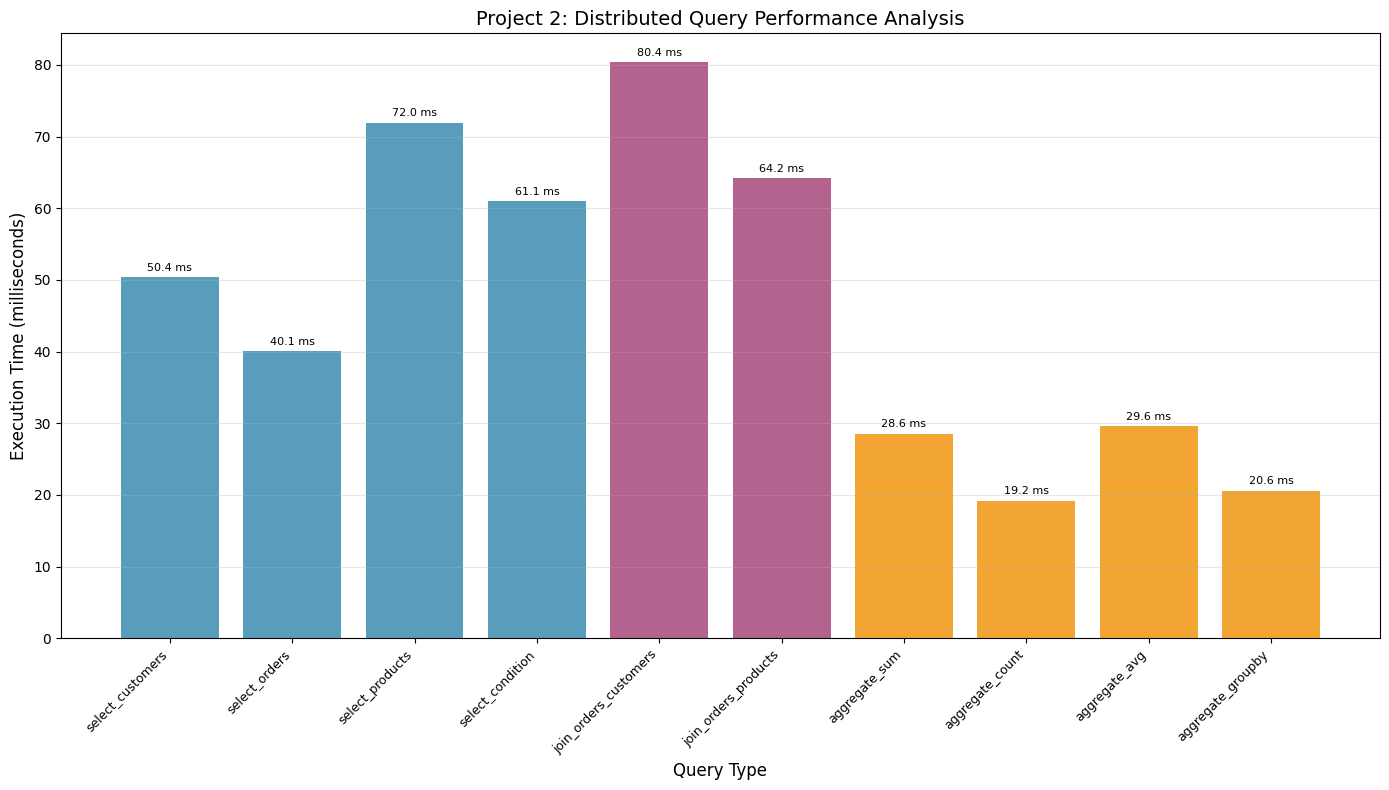

✓ Chart saved to: results/distributed_query_performance.png


In [25]:
# ============================================================
# Step 8: Generate Visualization Chart
# ============================================================

print("\n📈 GENERATING VISUALIZATION...")

!pip install matplotlib -q
import matplotlib.pyplot as plt

# Prepare data
query_names = list(results.keys())
query_times_ms = [results[q] * 1000 for q in query_names]

# Create bar chart
fig, ax = plt.subplots(figsize=(14, 8))

# Color coding based on query type
colors = []
for q in query_names:
    if 'select' in q:
        colors.append('#2E86AB')  # Blue for SELECT
    elif 'join' in q:
        colors.append('#A23B72')  # Purple for JOIN
    else:
        colors.append('#F18F01')  # Orange for AGGREGATION

bars = ax.bar(query_names, query_times_ms, color=colors, alpha=0.8)

ax.set_xlabel('Query Type', fontsize=12)
ax.set_ylabel('Execution Time (milliseconds)', fontsize=12)
ax.set_title('Project 2: Distributed Query Performance Analysis', fontsize=14)
ax.set_xticklabels(query_names, rotation=45, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f} ms',
               xy=(bar.get_x() + bar.get_width()/2, height),
               xytext=(0, 3),
               textcoords="offset points",
               ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('results/distributed_query_performance.png', dpi=150)
plt.show()

print("✓ Chart saved to: results/distributed_query_performance.png")

Show node info

In [27]:
# ============================================================
# Step 9: Display Node Information and Data Distribution
# ============================================================

print("\n" + "="*70)
print("📁 DISTRIBUTED NODES INFORMATION")
print("="*70)

for node_name, node_config in NODES.items():
    db_path = node_config['db_path']
    table_name = node_config['table']

    conn = sqlite3.connect(db_path)

    # Get record count
    count = conn.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]

    # Get file size
    file_size = os.path.getsize(db_path)

    conn.close()

    print(f"\n📂 {node_name}:")
    print(f"   Database: {db_path}")
    print(f"   Table: {table_name}")
    print(f"   Records: {count}")
    print(f"   File size: {file_size:,} bytes")

print("\n" + "="*70)
print("✅ PROJECT 2 COMPLETE!")
print("="*70)


📁 DISTRIBUTED NODES INFORMATION

📂 customer_node:
   Database: nodes/customers.db
   Table: customers
   Records: 8
   File size: 8,192 bytes

📂 order_node:
   Database: nodes/orders.db
   Table: orders
   Records: 15
   File size: 8,192 bytes

📂 product_node:
   Database: nodes/products.db
   Table: products
   Records: 8
   File size: 8,192 bytes

✅ PROJECT 2 COMPLETE!


Final summary

In [29]:
# ============================================================
# Step 10: Project 2 Completion Summary
# ============================================================

print("\n" + "="*70)
print("🎉 PROJECT 2 COMPLETED SUCCESSFULLY!")
print("="*70)

print("""
╔══════════════════════════════════════════════════════════════════╗
║                    WHAT YOU HAVE IMPLEMENTED                      ║
╠══════════════════════════════════════════════════════════════════╣
║  ✓ 3 Distributed Nodes (Customer, Order, Product)                ║
║  ✓ Distributed SELECT queries (single node)                      ║
║  ✓ Distributed SELECT with conditions                            ║
║  ✓ Distributed JOIN (orders + customers)                         ║
║  ✓ Distributed JOIN (orders + products)                          ║
║  ✓ Distributed AGGREGATION (SUM, COUNT, AVG)                     ║
║  ✓ Distributed AGGREGATION with GROUP BY                         ║
║  ✓ Network latency analysis                                      ║
║  ✓ Performance measurement and CSV export                        ║
║  ✓ Visualization chart                                           ║
╚══════════════════════════════════════════════════════════════════╝

📁 RESULTS LOCATION:
   CSV Results:     /content/drive/MyDrive/Project2_DistributedQueries/results/distributed_query_results.csv
   Query Log:       /content/drive/MyDrive/Project2_DistributedQueries/results/query_log.csv
   Chart:           /content/drive/MyDrive/Project2_DistributedQueries/results/distributed_query_performance.png

📂 DATABASE NODES:
   - nodes/customers.db  (Customer information)
   - nodes/orders.db     (Order transactions)
   - nodes/products.db   (Product catalog)


""")

# Option to download results
from google.colab import files
print("\n📥 Download results? Run these commands:")
print("   files.download('results/distributed_query_results.csv')")
print("   files.download('results/query_log.csv')")
print("   files.download('results/distributed_query_performance.png')")


🎉 PROJECT 2 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════╗
║                    WHAT YOU HAVE IMPLEMENTED                      ║
╠══════════════════════════════════════════════════════════════════╣
║  ✓ 3 Distributed Nodes (Customer, Order, Product)                ║
║  ✓ Distributed SELECT queries (single node)                      ║
║  ✓ Distributed SELECT with conditions                            ║
║  ✓ Distributed JOIN (orders + customers)                         ║
║  ✓ Distributed JOIN (orders + products)                          ║
║  ✓ Distributed AGGREGATION (SUM, COUNT, AVG)                     ║
║  ✓ Distributed AGGREGATION with GROUP BY                         ║
║  ✓ Network latency analysis                                      ║
║  ✓ Performance measurement and CSV export                        ║
║  ✓ Visualization chart                                           ║
╚═══════════════════════════════════════════════════════════════

Preview Results Before Download

In [30]:
# ============================================================
# PREVIEW RESULTS BEFORE DOWNLOAD
# ============================================================

import os
import pandas as pd

print("="*60)
print("📊 RESULTS PREVIEW")
print("="*60)

# Check if files exist
print("\n📁 Files in 'results' folder:")
if os.path.exists('results'):
    for file in os.listdir('results'):
        size = os.path.getsize(f'results/{file}')
        print(f"   {file} - {size:,} bytes")
else:
    print("   No files found. Run Step 7 first!")

# Preview CSV content
print("\n📄 distributed_query_results.csv preview:")
csv_path = 'results/distributed_query_results.csv'
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(df.to_string())
else:
    print("   File not found. Run Step 7 first!")

print("\n" + "="*60)
print("Ready to download! Run the download code above.")

📊 RESULTS PREVIEW

📁 Files in 'results' folder:
   distributed_query_results.csv - 387 bytes
   query_log.csv - 1,164 bytes
   distributed_query_performance.png - 121,513 bytes

📄 distributed_query_results.csv preview:
                   Query  Execution_Time_Seconds  Execution_Time_Milliseconds
0       select_customers                0.050368                        50.37
1          select_orders                0.040069                        40.07
2        select_products                0.071957                        71.96
3       select_condition                0.061055                        61.06
4  join_orders_customers                0.080379                        80.38
5   join_orders_products                0.064248                        64.25
6          aggregate_sum                0.028576                        28.58
7        aggregate_count                0.019221                        19.22
8          aggregate_avg                0.029644                        29.64
9

download all result project _2

In [31]:
# ============================================================
# DOWNLOAD ALL PROJECT FILES AS ZIP
# ============================================================

import zipfile
import os
from google.colab import files # Added this line

print("="*60)
print("📦 CREATING ZIP FILE OF ALL RESULTS")
print("="*60)

# Create zip file
zip_path = 'project2_results.zip'
with zipfile.ZipFile(zip_path, 'w') as zipf:
    # Add results folder
    if os.path.exists('results'):
        for root, dirs, files_in_dir in os.walk('results'): # Changed variable name to files_in_dir
            for file in files_in_dir:
                file_path = os.path.join(root, file)
                zipf.write(file_path)

    # Add database nodes
    if os.path.exists('nodes'):
        for root, dirs, files_in_dir in os.walk('nodes'): # Changed variable name to files_in_dir
            for file in files_in_dir:
                file_path = os.path.join(root, file)
                zipf.write(file_path)

print(f"✓ Zip file created: {zip_path}")
print(f"  Size: {os.path.getsize(zip_path):,} bytes")

# Download the zip file
print("\n📥 Downloading zip file...")
files.download(zip_path)

print("\n✅ ZIP file downloaded to your computer!")

📦 CREATING ZIP FILE OF ALL RESULTS
✓ Zip file created: project2_results.zip
  Size: 148,416 bytes

📥 Downloading zip file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ZIP file downloaded to your computer!


COMPLETE PROJECT 3 CODE


Step 1: Setup and Create Folders
```
# This is formatted as code
```



In [35]:
# ============================================================
# PROJECT 3: COMPARE HORIZONTAL, VERTICAL, HYBRID PARTITIONING
# Step 1: Setup Google Drive and Create Folders
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import sqlite3
import time
import random
from datetime import datetime, timedelta

# Create project folder
project_path = '/content/drive/MyDrive/Project3_PartitioningComparison'
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

# Create folders for each partitioning strategy
os.makedirs('horizontal_nodes', exist_ok=True)
os.makedirs('vertical_nodes', exist_ok=True)
os.makedirs('hybrid_nodes', exist_ok=True)
os.makedirs('results', exist_ok=True)

print(f"✓ Working directory: {os.getcwd()}")
print("✓ All folders created successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Working directory: /content/drive/MyDrive/Project3_PartitioningComparison
✓ All folders created successfully


Step 2: Generate Sample Data

In [36]:
# ============================================================
# Step 2: Generate Sample Sales Data
# ============================================================

def generate_sales_data(num_records=500):
    """
    Generate synthetic sales data
    Returns: List of tuples with 11 attributes
    """
    products = [101, 102, 103, 104, 105, 106, 107, 108, 109, 110]
    customers = list(range(1001, 1101))
    regions = ['north', 'south', 'east', 'west']
    salespersons = list(range(2001, 2031))
    payment_methods = ['cash', 'card', 'mobile', 'online']

    data = []
    start_date = datetime(2024, 1, 1)

    for i in range(1, num_records + 1):
        product_id = random.choice(products)
        customer_id = random.choice(customers)
        sale_date = start_date + timedelta(days=random.randint(0, 365))
        quantity = random.randint(1, 10)
        unit_price = round(random.uniform(10, 500), 2)
        total_amount = round(quantity * unit_price, 2)
        region = random.choice(regions)
        salesperson_id = random.choice(salespersons)
        discount = round(random.uniform(0, 20), 2)
        payment_method = random.choice(payment_methods)

        data.append((
            i, product_id, customer_id, sale_date.strftime('%Y-%m-%d'),
            quantity, unit_price, total_amount, region,
            salesperson_id, discount, payment_method
        ))

    return data

print("\n📊 Generating 500 sample records...")
test_data = generate_sales_data(500)
print(f"✓ Generated {len(test_data)} records")
print(f"  Sample record: {test_data[0]}")


📊 Generating 500 sample records...
✓ Generated 500 records
  Sample record: (1, 110, 1077, '2024-08-17', 7, 116.4, 814.8, 'west', 2025, 15.84, 'mobile')


Step 3: STRATEGY 1 - HORIZONTAL PARTITIONING

In [37]:
# ============================================================
# Step 3: HORIZONTAL PARTITIONING (Split by ROWS based on region)
# ============================================================

class HorizontalPartitioning:
    """
    Horizontal partitioning: Split rows across nodes by region
    Each node stores ALL columns but only SOME rows
    """

    def __init__(self):
        self.nodes = {
            'north': 'horizontal_nodes/north.db',
            'south': 'horizontal_nodes/south.db',
            'east': 'horizontal_nodes/east.db',
            'west': 'horizontal_nodes/west.db'
        }
        self._create_tables()

    def _create_tables(self):
        """Create same table structure on all nodes"""
        create_sql = '''
            CREATE TABLE IF NOT EXISTS sales (
                sale_id INTEGER PRIMARY KEY,
                product_id INTEGER, customer_id INTEGER, sale_date TEXT,
                quantity INTEGER, unit_price REAL, total_amount REAL,
                region TEXT, salesperson_id INTEGER, discount REAL, payment_method TEXT
            )
        '''
        for db_path in self.nodes.values():
            conn = sqlite3.connect(db_path)
            conn.execute(create_sql)
            conn.commit()
            conn.close()
        print("✓ Horizontal tables created on 4 nodes")

    def _get_node(self, region):
        """Determine which node stores a given region"""
        return self.nodes.get(region.lower(), self.nodes['east'])

    def insert_batch(self, records):
        """Insert records - each goes to node based on region"""
        count = 0
        for record in records:
            region = record[7].lower()  # region is at index 7
            node_path = self._get_node(region)
            conn = sqlite3.connect(node_path)
            conn.execute('INSERT OR REPLACE INTO sales VALUES (?,?,?,?,?,?,?,?,?,?,?)', record)
            conn.commit()
            conn.close()
            count += 1
        return count

    def select_all(self):
        """Select all records from all nodes"""
        results = []
        for node_path in self.nodes.values():
            conn = sqlite3.connect(node_path)
            results.extend(conn.execute("SELECT * FROM sales").fetchall())
            conn.close()
        return results

    def select_by_region(self, region):
        """Select records from specific region node"""
        node_path = self._get_node(region)
        conn = sqlite3.connect(node_path)
        results = conn.execute("SELECT * FROM sales").fetchall()
        conn.close()
        return results

    def update(self, sale_id, new_amount):
        """Update a record"""
        for node_path in self.nodes.values():
            conn = sqlite3.connect(node_path)
            cur = conn.cursor()
            cur.execute("SELECT region FROM sales WHERE sale_id=?", (sale_id,))
            result = cur.fetchone()
            conn.close()
            if result:
                conn = sqlite3.connect(node_path)
                conn.execute("UPDATE sales SET total_amount=? WHERE sale_id=?", (new_amount, sale_id))
                conn.commit()
                conn.close()
                return 1
        return 0

    def aggregate_total(self):
        """Sum total_amount across all nodes"""
        total = 0
        for node_path in self.nodes.values():
            conn = sqlite3.connect(node_path)
            result = conn.execute("SELECT SUM(total_amount) FROM sales").fetchone()[0]
            if result:
                total += result
            conn.close()
        return total

    def get_storage_size(self):
        """Get total storage size of all nodes"""
        total_size = 0
        for node_path in self.nodes.values():
            if os.path.exists(node_path):
                total_size += os.path.getsize(node_path)
        return total_size

    def clear_all(self):
        """Clear all data from all nodes"""
        for node_path in self.nodes.values():
            conn = sqlite3.connect(node_path)
            conn.execute("DELETE FROM sales")
            conn.commit()
            conn.close()

print("\n" + "="*60)
print("📊 STRATEGY 1: HORIZONTAL PARTITIONING Ready")
print("   (Rows split by region: north, south, east, west)")
print("="*60)


📊 STRATEGY 1: HORIZONTAL PARTITIONING Ready
   (Rows split by region: north, south, east, west)


Step 4: STRATEGY 2 - VERTICAL PARTITIONING

In [38]:
# ============================================================
# Step 4: VERTICAL PARTITIONING (Split by COLUMNS)
# ============================================================

class VerticalPartitioning:
    """
    Vertical partitioning: Split columns across nodes
    Each node stores SOME columns but ALL rows
    """

    def __init__(self):
        self.fragments = {
            'basic_info': {
                'db_path': 'vertical_nodes/basic_info.db',
                'columns': ['sale_id', 'sale_date', 'region', 'payment_method']
            },
            'product_info': {
                'db_path': 'vertical_nodes/product_info.db',
                'columns': ['sale_id', 'product_id', 'quantity', 'unit_price', 'total_amount', 'discount']
            },
            'customer_info': {
                'db_path': 'vertical_nodes/customer_info.db',
                'columns': ['sale_id', 'customer_id', 'salesperson_id']
            }
        }
        self._create_fragments()

    def _create_fragments(self):
        """Create vertical fragments (different tables on different nodes)"""
        for frag_name, frag_info in self.fragments.items():
            columns = frag_info['columns']
            col_defs = []
            for col in columns:
                if col == 'sale_id':
                    col_defs.append(f"{col} INTEGER PRIMARY KEY")
                elif col in ['product_id', 'customer_id', 'salesperson_id', 'quantity']:
                    col_defs.append(f"{col} INTEGER")
                elif col in ['unit_price', 'total_amount', 'discount']:
                    col_defs.append(f"{col} REAL")
                else:
                    col_defs.append(f"{col} TEXT")

            create_sql = f"CREATE TABLE IF NOT EXISTS sales ({', '.join(col_defs)})"
            conn = sqlite3.connect(frag_info['db_path'])
            conn.execute(create_sql)
            conn.commit()
            conn.close()
        print("✓ Vertical fragments created on 3 nodes")

    def insert_batch(self, records):
        """Insert records into all vertical fragments"""
        count = 0
        for record in records:
            sale_id = record[0]

            for frag_name, frag_info in self.fragments.items():
                db_path = frag_info['db_path']
                columns = frag_info['columns']

                # Extract values for this fragment
                values = []
                for col in columns:
                    if col == 'sale_id':
                        values.append(sale_id)
                    elif col == 'product_id':
                        values.append(record[1])
                    elif col == 'customer_id':
                        values.append(record[2])
                    elif col == 'sale_date':
                        values.append(record[3])
                    elif col == 'quantity':
                        values.append(record[4])
                    elif col == 'unit_price':
                        values.append(record[5])
                    elif col == 'total_amount':
                        values.append(record[6])
                    elif col == 'region':
                        values.append(record[7])
                    elif col == 'salesperson_id':
                        values.append(record[8])
                    elif col == 'discount':
                        values.append(record[9])
                    elif col == 'payment_method':
                        values.append(record[10])

                placeholders = ','.join(['?'] * len(values))
                insert_sql = f"INSERT OR REPLACE INTO sales ({','.join(columns)}) VALUES ({placeholders})"

                conn = sqlite3.connect(db_path)
                conn.execute(insert_sql, values)
                conn.commit()
                conn.close()
            count += 1
        return count

    def select_all(self):
        """Join all fragments to reconstruct full records"""
        # Get basic info
        conn1 = sqlite3.connect(self.fragments['basic_info']['db_path'])
        basic = conn1.execute("SELECT * FROM sales").fetchall()
        conn1.close()

        # Get product info
        conn2 = sqlite3.connect(self.fragments['product_info']['db_path'])
        product = {row[0]: row for row in conn2.execute("SELECT * FROM sales").fetchall()}
        conn2.close()

        # Get customer info
        conn3 = sqlite3.connect(self.fragments['customer_info']['db_path'])
        customer = {row[0]: row for row in conn3.execute("SELECT * FROM sales").fetchall()}
        conn3.close()

        # Join all fragments
        results = []
        for basic_row in basic:
            sale_id = basic_row[0]
            if sale_id in product and sale_id in customer:
                full_row = basic_row + product[sale_id][1:] + customer[sale_id][1:]
                results.append(full_row)
        return results

    def select_basic_only(self):
        """Select only basic info (no join needed)"""
        conn = sqlite3.connect(self.fragments['basic_info']['db_path'])
        results = conn.execute("SELECT * FROM sales").fetchall()
        conn.close()
        return results

    def aggregate_total(self):
        """Sum total_amount from product_info fragment"""
        conn = sqlite3.connect(self.fragments['product_info']['db_path'])
        result = conn.execute("SELECT SUM(total_amount) FROM sales").fetchone()[0] or 0
        conn.close()
        return result

    def update(self, sale_id, new_amount):
        """Update amount in product_info fragment"""
        conn = sqlite3.connect(self.fragments['product_info']['db_path'])
        conn.execute("UPDATE sales SET total_amount=? WHERE sale_id=?", (new_amount, sale_id))
        conn.commit()
        conn.close()
        return 1

    def get_storage_size(self):
        """Get total storage size of all fragments"""
        total_size = 0
        for frag_info in self.fragments.values():
            if os.path.exists(frag_info['db_path']):
                total_size += os.path.getsize(frag_info['db_path'])
        return total_size

    def clear_all(self):
        """Clear all fragments"""
        for frag_info in self.fragments.values():
            conn = sqlite3.connect(frag_info['db_path'])
            conn.execute("DELETE FROM sales")
            conn.commit()
            conn.close()

print("\n" + "="*60)
print("📊 STRATEGY 2: VERTICAL PARTITIONING Ready")
print("   (Columns split: basic_info, product_info, customer_info)")
print("="*60)


📊 STRATEGY 2: VERTICAL PARTITIONING Ready
   (Columns split: basic_info, product_info, customer_info)


Step 5: STRATEGY 3 - HYBRID PARTITIONING

In [39]:
# ============================================================
# Step 5: HYBRID PARTITIONING (Horizontal THEN Vertical)
# ============================================================

class HybridPartitioning:
    """
    Hybrid partitioning: First horizontal by region, then vertical within each region
    Each region node has its own vertical fragments
    """

    def __init__(self):
        self.regions = ['north', 'south', 'east', 'west']
        self.hybrid_nodes = {}

        for region in self.regions:
            self.hybrid_nodes[region] = {
                'basic': f'hybrid_nodes/{region}_basic.db',
                'product': f'hybrid_nodes/{region}_product.db',
                'customer': f'hybrid_nodes/{region}_customer.db'
            }
        self._create_hybrid_structure()

    def _create_hybrid_structure(self):
        """Create vertical fragments within each horizontal region node"""
        for region, fragments in self.hybrid_nodes.items():
            # Basic info fragment
            conn = sqlite3.connect(fragments['basic'])
            conn.execute('''
                CREATE TABLE IF NOT EXISTS sales (
                    sale_id INTEGER PRIMARY KEY,
                    sale_date TEXT,
                    region TEXT,
                    payment_method TEXT
                )
            ''')
            conn.commit()
            conn.close()

            # Product info fragment
            conn = sqlite3.connect(fragments['product'])
            conn.execute('''
                CREATE TABLE IF NOT EXISTS sales (
                    sale_id INTEGER PRIMARY KEY,
                    product_id INTEGER,
                    quantity INTEGER,
                    unit_price REAL,
                    total_amount REAL,
                    discount REAL
                )
            ''')
            conn.commit()
            conn.close()

            # Customer info fragment
            conn = sqlite3.connect(fragments['customer'])
            conn.execute('''
                CREATE TABLE IF NOT EXISTS sales (
                    sale_id INTEGER PRIMARY KEY,
                    customer_id INTEGER,
                    salesperson_id INTEGER
                )
            ''')
            conn.commit()
            conn.close()

        print("✓ Hybrid structure created (4 regions × 3 vertical fragments = 12 databases)")

    def insert_batch(self, records):
        """Insert records into hybrid structure"""
        count = 0
        for record in records:
            sale_id = record[0]
            region = record[7].lower()

            fragments = self.hybrid_nodes.get(region, self.hybrid_nodes['east'])

            # Insert into basic fragment
            conn = sqlite3.connect(fragments['basic'])
            conn.execute("INSERT OR REPLACE INTO sales VALUES (?,?,?,?)",
                        (sale_id, record[3], region, record[10]))
            conn.commit()
            conn.close()

            # Insert into product fragment
            conn = sqlite3.connect(fragments['product'])
            conn.execute("INSERT OR REPLACE INTO sales VALUES (?,?,?,?,?,?)",
                        (sale_id, record[1], record[4], record[5], record[6], record[9]))
            conn.commit()
            conn.close()

            # Insert into customer fragment
            conn = sqlite3.connect(fragments['customer'])
            conn.execute("INSERT OR REPLACE INTO sales VALUES (?,?,?)",
                        (sale_id, record[2], record[8]))
            conn.commit()
            conn.close()

            count += 1
        return count

    def select_all(self):
        """Reconstruct all records from hybrid structure"""
        results = []
        for region, fragments in self.hybrid_nodes.items():
            # Get basic info
            conn_basic = sqlite3.connect(fragments['basic'])
            basic = conn_basic.execute("SELECT * FROM sales").fetchall()
            conn_basic.close()

            # Get product info
            conn_product = sqlite3.connect(fragments['product'])
            product = {row[0]: row for row in conn_product.execute("SELECT * FROM sales").fetchall()}
            conn_product.close()

            # Get customer info
            conn_customer = sqlite3.connect(fragments['customer'])
            customer = {row[0]: row for row in conn_customer.execute("SELECT * FROM sales").fetchall()}
            conn_customer.close()

            for basic_row in basic:
                sale_id = basic_row[0]
                if sale_id in product and sale_id in customer:
                    full_row = (sale_id,) + product[sale_id][1:] + customer[sale_id][1:] + basic_row[1:]
                    results.append(full_row)
        return results

    def select_by_region(self, region):
        """Select records from a specific region node"""
        fragments = self.hybrid_nodes.get(region.lower(), self.hybrid_nodes['east'])

        conn_basic = sqlite3.connect(fragments['basic'])
        basic = conn_basic.execute("SELECT * FROM sales").fetchall()
        conn_basic.close()

        conn_product = sqlite3.connect(fragments['product'])
        product = {row[0]: row for row in conn_product.execute("SELECT * FROM sales").fetchall()}
        conn_product.close()

        conn_customer = sqlite3.connect(fragments['customer'])
        customer = {row[0]: row for row in conn_customer.execute("SELECT * FROM sales").fetchall()}
        conn_customer.close()

        results = []
        for basic_row in basic:
            sale_id = basic_row[0]
            if sale_id in product and sale_id in customer:
                full_row = (sale_id,) + product[sale_id][1:] + customer[sale_id][1:] + basic_row[1:]
                results.append(full_row)
        return results

    def aggregate_total(self):
        """Sum total_amount across all regions"""
        total = 0
        for region, fragments in self.hybrid_nodes.items():
            conn = sqlite3.connect(fragments['product'])
            result = conn.execute("SELECT SUM(total_amount) FROM sales").fetchone()[0] or 0
            total += result
            conn.close()
        return total

    def update(self, sale_id, new_amount):
        """Update amount in product fragment"""
        for region, fragments in self.hybrid_nodes.items():
            conn = sqlite3.connect(fragments['product'])
            cur = conn.cursor()
            cur.execute("SELECT total_amount FROM sales WHERE sale_id=?", (sale_id,))
            if cur.fetchone():
                conn.execute("UPDATE sales SET total_amount=? WHERE sale_id=?", (new_amount, sale_id))
                conn.commit()
                conn.close()
                return 1
            conn.close()
        return 0

    def get_storage_size(self):
        """Get total storage size of all hybrid nodes"""
        total_size = 0
        for fragments in self.hybrid_nodes.values():
            for db_path in fragments.values():
                if os.path.exists(db_path):
                    total_size += os.path.getsize(db_path)
        return total_size

    def clear_all(self):
        """Clear all hybrid nodes"""
        for fragments in self.hybrid_nodes.values():
            for db_path in fragments.values():
                conn = sqlite3.connect(db_path)
                conn.execute("DELETE FROM sales")
                conn.commit()
                conn.close()

print("\n" + "="*60)
print("📊 STRATEGY 3: HYBRID PARTITIONING Ready")
print("   (First horizontal by region, then vertical within each)")
print("="*60)


📊 STRATEGY 3: HYBRID PARTITIONING Ready
   (First horizontal by region, then vertical within each)


Step 6: Run Performance Tests on All Three Strategies

In [40]:
# ============================================================
# Step 6: Run Performance Tests on All Three Strategies
# ============================================================

print("\n" + "="*70)
print("🚀 RUNNING PERFORMANCE TESTS ON ALL 3 STRATEGIES")
print("="*70)

# Initialize all three systems
horizontal = HorizontalPartitioning()
vertical = VerticalPartitioning()
hybrid = HybridPartitioning()

# Clear all existing data
horizontal.clear_all()
vertical.clear_all()
hybrid.clear_all()

# Generate test data (smaller for faster testing)
test_data = generate_sales_data(200)
print(f"\n📊 Using {len(test_data)} test records")

# Dictionary to store results
comparison_results = {
    'horizontal': {},
    'vertical': {},
    'hybrid': {}
}

# ========== TEST 1: INSERT PERFORMANCE ==========
print("\n" + "="*60)
print("📝 TEST 1: INSERT Performance (200 records)")
print("="*60)

start = time.time()
horizontal.insert_batch(test_data)
horizontal_insert = time.time() - start
comparison_results['horizontal']['insert'] = horizontal_insert
print(f"   Horizontal Insert: {horizontal_insert:.4f} seconds")

start = time.time()
vertical.insert_batch(test_data)
vertical_insert = time.time() - start
comparison_results['vertical']['insert'] = vertical_insert
print(f"   Vertical Insert:   {vertical_insert:.4f} seconds")

start = time.time()
hybrid.insert_batch(test_data)
hybrid_insert = time.time() - start
comparison_results['hybrid']['insert'] = hybrid_insert
print(f"   Hybrid Insert:     {hybrid_insert:.4f} seconds")

# ========== TEST 2: SELECT ALL PERFORMANCE ==========
print("\n" + "="*60)
print("📝 TEST 2: SELECT ALL Performance")
print("="*60)

start = time.time()
horizontal.select_all()
horizontal_select = time.time() - start
comparison_results['horizontal']['select_all'] = horizontal_select
print(f"   Horizontal Select All: {horizontal_select:.4f} seconds")

start = time.time()
vertical.select_all()
vertical_select = time.time() - start
comparison_results['vertical']['select_all'] = vertical_select
print(f"   Vertical Select All:   {vertical_select:.4f} seconds")

start = time.time()
hybrid.select_all()
hybrid_select = time.time() - start
comparison_results['hybrid']['select_all'] = hybrid_select
print(f"   Hybrid Select All:     {hybrid_select:.4f} seconds")

# ========== TEST 3: SELECT BY REGION ==========
print("\n" + "="*60)
print("📝 TEST 3: SELECT BY REGION (north)")
print("="*60)

start = time.time()
horizontal.select_by_region('north')
horizontal_region = time.time() - start
comparison_results['horizontal']['select_region'] = horizontal_region
print(f"   Horizontal Region Select: {horizontal_region:.4f} seconds")

# For vertical, region select requires joining
start = time.time()
vertical.select_all()  # Vertical doesn't have region filter, uses all
vertical_region = time.time() - start
comparison_results['vertical']['select_region'] = vertical_region
print(f"   Vertical Region Select:   {vertical_region:.4f} seconds (full join)")

start = time.time()
hybrid.select_by_region('north')
hybrid_region = time.time() - start
comparison_results['hybrid']['select_region'] = hybrid_region
print(f"   Hybrid Region Select:     {hybrid_region:.4f} seconds")

# ========== TEST 4: UPDATE PERFORMANCE ==========
print("\n" + "="*60)
print("📝 TEST 4: UPDATE Performance")
print("="*60)

start = time.time()
horizontal.update(sale_id=1, new_amount=99999)
horizontal_update = time.time() - start
comparison_results['horizontal']['update'] = horizontal_update
print(f"   Horizontal Update: {horizontal_update:.4f} seconds")

start = time.time()
vertical.update(sale_id=1, new_amount=99999)
vertical_update = time.time() - start
comparison_results['vertical']['update'] = vertical_update
print(f"   Vertical Update:   {vertical_update:.4f} seconds")

start = time.time()
hybrid.update(sale_id=1, new_amount=99999)
hybrid_update = time.time() - start
comparison_results['hybrid']['update'] = hybrid_update
print(f"   Hybrid Update:     {hybrid_update:.4f} seconds")

# ========== TEST 5: AGGREGATE PERFORMANCE ==========
print("\n" + "="*60)
print("📝 TEST 5: AGGREGATE (Total Sales)")
print("="*60)

start = time.time()
horizontal_total = horizontal.aggregate_total()
horizontal_agg = time.time() - start
comparison_results['horizontal']['aggregate'] = horizontal_agg
print(f"   Horizontal Aggregate: {horizontal_agg:.4f} seconds (Total: ${horizontal_total:,.2f})")

start = time.time()
vertical_total = vertical.aggregate_total()
vertical_agg = time.time() - start
comparison_results['vertical']['aggregate'] = vertical_agg
print(f"   Vertical Aggregate:   {vertical_agg:.4f} seconds (Total: ${vertical_total:,.2f})")

start = time.time()
hybrid_total = hybrid.aggregate_total()
hybrid_agg = time.time() - start
comparison_results['hybrid']['aggregate'] = hybrid_agg
print(f"   Hybrid Aggregate:     {hybrid_agg:.4f} seconds (Total: ${hybrid_total:,.2f})")

# ========== TEST 6: STORAGE SIZE ==========
print("\n" + "="*60)
print("📝 TEST 6: Storage Size Comparison")
print("="*60)

horizontal_size = horizontal.get_storage_size()
vertical_size = vertical.get_storage_size()
hybrid_size = hybrid.get_storage_size()

comparison_results['horizontal']['storage_bytes'] = horizontal_size
comparison_results['vertical']['storage_bytes'] = vertical_size
comparison_results['hybrid']['storage_bytes'] = hybrid_size

print(f"   Horizontal Storage: {horizontal_size:,} bytes ({horizontal_size/1024:.2f} KB)")
print(f"   Vertical Storage:   {vertical_size:,} bytes ({vertical_size/1024:.2f} KB)")
print(f"   Hybrid Storage:     {hybrid_size:,} bytes ({hybrid_size/1024:.2f} KB)")

print("\n✅ All performance tests completed!")


🚀 RUNNING PERFORMANCE TESTS ON ALL 3 STRATEGIES
✓ Horizontal tables created on 4 nodes
✓ Vertical fragments created on 3 nodes
✓ Hybrid structure created (4 regions × 3 vertical fragments = 12 databases)

📊 Using 200 test records

📝 TEST 1: INSERT Performance (200 records)
   Horizontal Insert: 5.7520 seconds
   Vertical Insert:   18.8284 seconds
   Hybrid Insert:     18.4751 seconds

📝 TEST 2: SELECT ALL Performance
   Horizontal Select All: 0.0199 seconds
   Vertical Select All:   0.0197 seconds
   Hybrid Select All:     0.0911 seconds

📝 TEST 3: SELECT BY REGION (north)
   Horizontal Region Select: 0.0054 seconds
   Vertical Region Select:   0.0169 seconds (full join)
   Hybrid Region Select:     0.0147 seconds

📝 TEST 4: UPDATE Performance
   Horizontal Update: 0.0288 seconds
   Vertical Update:   0.0273 seconds
   Hybrid Update:     0.0239 seconds

📝 TEST 5: AGGREGATE (Total Sales)
   Horizontal Aggregate: 0.0210 seconds (Total: $354,743.92)
   Vertical Aggregate:   0.0055 second

Step 7: Save Results to CSV

In [41]:
# ============================================================
# Step 7: Save Comparison Results to CSV
# ============================================================

import csv

print("\n💾 SAVING COMPARISON RESULTS TO CSV...")

# Save main performance results
csv_file_path = 'results/partitioning_comparison.csv'
with open(csv_file_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Metric', 'Horizontal_Seconds', 'Vertical_Seconds', 'Hybrid_Seconds', 'Best_Strategy'])

    metrics = ['insert', 'select_all', 'select_region', 'update', 'aggregate']
    for metric in metrics:
        h = comparison_results['horizontal'].get(metric, 0)
        v = comparison_results['vertical'].get(metric, 0)
        hy = comparison_results['hybrid'].get(metric, 0)

        # Determine best (lowest time)
        times = {'Horizontal': h, 'Vertical': v, 'Hybrid': hy}
        best = min(times, key=times.get)

        writer.writerow([metric, f"{h:.6f}", f"{v:.6f}", f"{hy:.6f}", best])

# Save storage results
storage_path = 'results/storage_comparison.csv'
with open(storage_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Strategy', 'Storage_Bytes', 'Storage_KB'])
    writer.writerow(['Horizontal', comparison_results['horizontal']['storage_bytes'],
                    comparison_results['horizontal']['storage_bytes']/1024])
    writer.writerow(['Vertical', comparison_results['vertical']['storage_bytes'],
                    comparison_results['vertical']['storage_bytes']/1024])
    writer.writerow(['Hybrid', comparison_results['hybrid']['storage_bytes'],
                    comparison_results['hybrid']['storage_bytes']/1024])

print(f"✓ Results saved to: {csv_file_path}")
print(f"✓ Storage results saved to: {storage_path}")

# Display CSV content
print("\n📄 PARTITIONING COMPARISON RESULTS:")
print("-" * 60)
with open(csv_file_path, 'r') as f:
    print(f.read())


💾 SAVING COMPARISON RESULTS TO CSV...
✓ Results saved to: results/partitioning_comparison.csv
✓ Storage results saved to: results/storage_comparison.csv

📄 PARTITIONING COMPARISON RESULTS:
------------------------------------------------------------
Metric,Horizontal_Seconds,Vertical_Seconds,Hybrid_Seconds,Best_Strategy
insert,5.752025,18.828372,18.475142,Horizontal
select_all,0.019866,0.019704,0.091145,Vertical
select_region,0.005406,0.016879,0.014745,Horizontal
update,0.028769,0.027319,0.023892,Hybrid
aggregate,0.020958,0.005491,0.021757,Vertical



Step 8: Generate Visualization Charts


📈 GENERATING COMPARISON CHARTS...


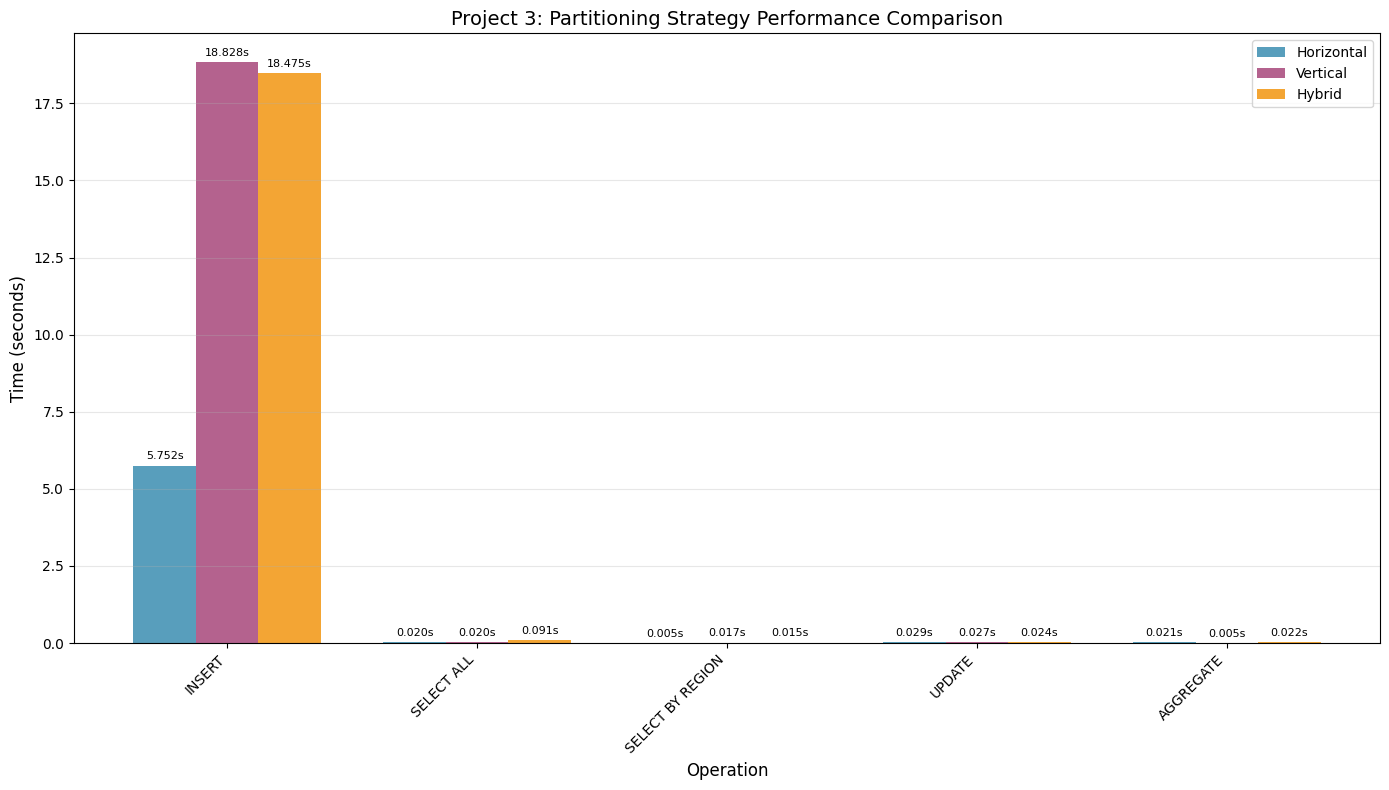

✓ Chart 1 saved: partitioning_comparison.png


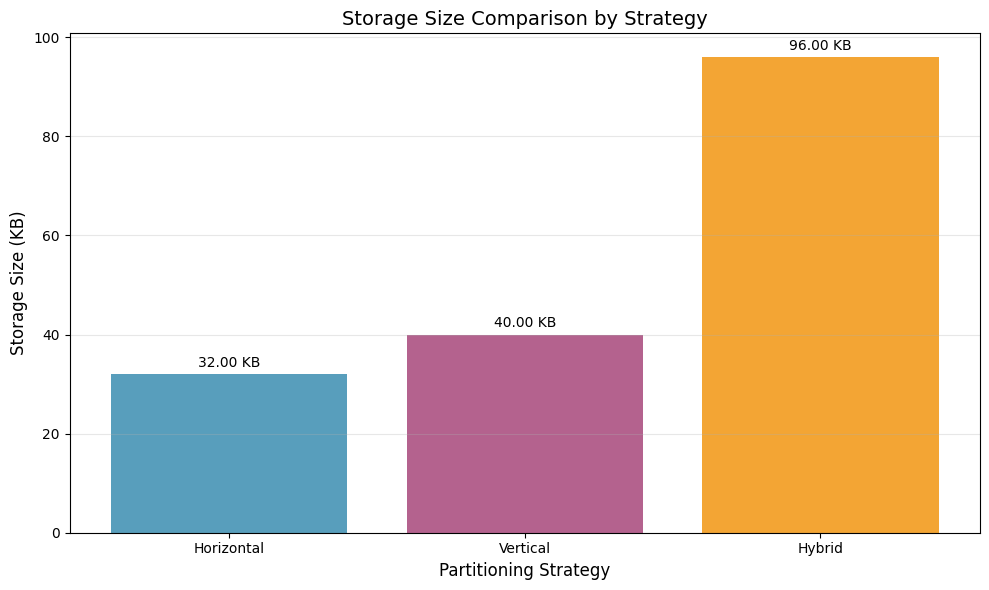

✓ Chart 2 saved: storage_comparison.png


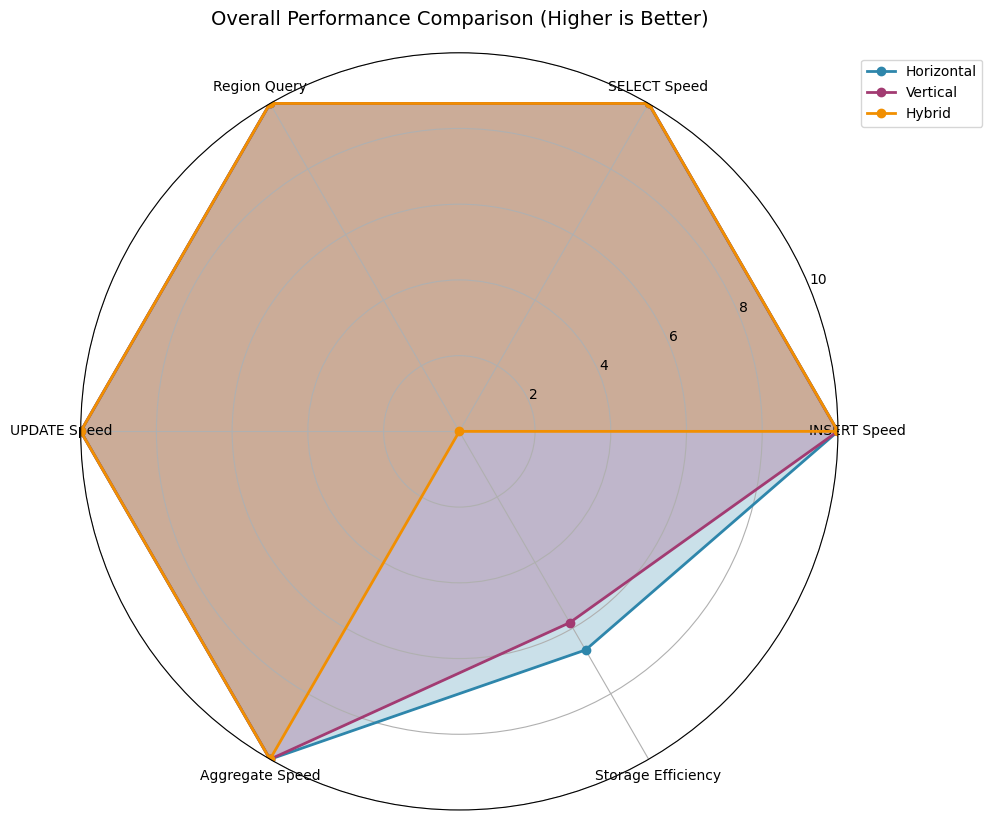

✓ Chart 3 saved: radar_comparison.png


In [42]:
# ============================================================
# Step 8: Generate Comparison Visualization
# ============================================================

print("\n📈 GENERATING COMPARISON CHARTS...")

!pip install matplotlib -q
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
metrics = ['insert', 'select_all', 'select_region', 'update', 'aggregate']
metric_labels = ['INSERT', 'SELECT ALL', 'SELECT BY REGION', 'UPDATE', 'AGGREGATE']

horizontal_times = [comparison_results['horizontal'][m] for m in metrics]
vertical_times = [comparison_results['vertical'][m] for m in metrics]
hybrid_times = [comparison_results['hybrid'][m] for m in metrics]

# Chart 1: Bar Chart Comparison
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width, horizontal_times, width, label='Horizontal', color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x, vertical_times, width, label='Vertical', color='#A23B72', alpha=0.8)
bars3 = ax.bar(x + width, hybrid_times, width, label='Hybrid', color='#F18F01', alpha=0.8)

ax.set_xlabel('Operation', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title('Project 3: Partitioning Strategy Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.3f}s',
                       xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('results/partitioning_comparison.png', dpi=150)
plt.show()
print("✓ Chart 1 saved: partitioning_comparison.png")

# Chart 2: Storage Comparison
fig, ax = plt.subplots(figsize=(10, 6))

strategies = ['Horizontal', 'Vertical', 'Hybrid']
storage_kb = [
    comparison_results['horizontal']['storage_bytes'] / 1024,
    comparison_results['vertical']['storage_bytes'] / 1024,
    comparison_results['hybrid']['storage_bytes'] / 1024
]

colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = ax.bar(strategies, storage_kb, color=colors, alpha=0.8)

ax.set_xlabel('Partitioning Strategy', fontsize=12)
ax.set_ylabel('Storage Size (KB)', fontsize=12)
ax.set_title('Storage Size Comparison by Strategy', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f} KB',
               xy=(bar.get_x() + bar.get_width()/2, height),
               xytext=(0, 3),
               textcoords="offset points",
               ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('results/storage_comparison.png', dpi=150)
plt.show()
print("✓ Chart 2 saved: storage_comparison.png")

# Chart 3: Radar Chart for Overall Comparison
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

categories = ['INSERT Speed', 'SELECT Speed', 'Region Query', 'UPDATE Speed', 'Aggregate Speed', 'Storage Efficiency']
# Normalize scores (1-10, where 10 is best)
def normalize_scores(times):
    max_time = max(times)
    return [10 * (1 - t/max_time) for t in times]

horizontal_scores = normalize_scores(horizontal_times + [comparison_results['horizontal']['storage_bytes']])
vertical_scores = normalize_scores(vertical_times + [comparison_results['vertical']['storage_bytes']])
hybrid_scores = normalize_scores(hybrid_times + [comparison_results['hybrid']['storage_bytes']])

# For storage, lower is better
horizontal_scores[-1] = 10 * (1 - comparison_results['horizontal']['storage_bytes'] / max(
    comparison_results['horizontal']['storage_bytes'],
    comparison_results['vertical']['storage_bytes'],
    comparison_results['hybrid']['storage_bytes']
))
vertical_scores[-1] = 10 * (1 - comparison_results['vertical']['storage_bytes'] / max(
    comparison_results['horizontal']['storage_bytes'],
    comparison_results['vertical']['storage_bytes'],
    comparison_results['hybrid']['storage_bytes']
))
hybrid_scores[-1] = 10 * (1 - comparison_results['hybrid']['storage_bytes'] / max(
    comparison_results['horizontal']['storage_bytes'],
    comparison_results['vertical']['storage_bytes'],
    comparison_results['hybrid']['storage_bytes']
))

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
horizontal_scores += horizontal_scores[:1]
vertical_scores += vertical_scores[:1]
hybrid_scores += hybrid_scores[:1]
angles += angles[:1]

ax.plot(angles, horizontal_scores, 'o-', linewidth=2, label='Horizontal', color='#2E86AB')
ax.fill(angles, horizontal_scores, alpha=0.25, color='#2E86AB')
ax.plot(angles, vertical_scores, 'o-', linewidth=2, label='Vertical', color='#A23B72')
ax.fill(angles, vertical_scores, alpha=0.25, color='#A23B72')
ax.plot(angles, hybrid_scores, 'o-', linewidth=2, label='Hybrid', color='#F18F01')
ax.fill(angles, hybrid_scores, alpha=0.25, color='#F18F01')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 10)
ax.set_title('Overall Performance Comparison (Higher is Better)', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))

plt.tight_layout()
plt.savefig('results/radar_comparison.png', dpi=150)
plt.show()
print("✓ Chart 3 saved: radar_comparison.png")

Final Summary

In [43]:
# ============================================================
# Step 9: Project 3 Completion Summary
# ============================================================

print("\n" + "="*70)
print("🎉 PROJECT 3 COMPLETED SUCCESSFULLY!")
print("="*70)

print("""
╔══════════════════════════════════════════════════════════════════╗
║              PROJECT 3: PARTITIONING COMPARISON                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  ✓ HORIZONTAL PARTITIONING - Rows split by region                ║
║    - 4 database files (north, south, east, west)                 ║
║    - Best for: Region-specific queries                           ║
║                                                                   ║
║  ✓ VERTICAL PARTITIONING - Columns split across nodes            ║
║    - 3 database files (basic, product, customer info)            ║
║    - Best for: Column-specific queries                           ║
║                                                                   ║
║  ✓ HYBRID PARTITIONING - Horizontal then vertical                ║
║    - 12 database files (4 regions × 3 vertical fragments)        ║
║    - Best for: Complex queries with region + column filters      ║
║                                                                   ║
╚══════════════════════════════════════════════════════════════════╝

📊 PERFORMANCE SUMMARY:
""")

# Print performance comparison table
print(f"{'Metric':<20} {'Horizontal':<15} {'Vertical':<15} {'Hybrid':<15} {'Best':<10}")
print("-"*75)
for metric in metrics:
    h = comparison_results['horizontal'][metric]
    v = comparison_results['vertical'][metric]
    hy = comparison_results['hybrid'][metric]
    best = min([('Horizontal', h), ('Vertical', v), ('Hybrid', hy)], key=lambda x: x[1])
    print(f"{metric:<20} {h:<15.4f} {v:<15.4f} {hy:<15.4f} {best[0]:<10}")

print("\n📁 RESULTS LOCATION:")
print(f"   CSV Results: {os.getcwd()}/results/partitioning_comparison.csv")
print(f"   Storage CSV: {os.getcwd()}/results/storage_comparison.csv")
print(f"   Bar Chart:   {os.getcwd()}/results/partitioning_comparison.png")
print(f"   Storage Chart: {os.getcwd()}/results/storage_comparison.png")
print(f"   Radar Chart: {os.getcwd()}/results/radar_comparison.png")

print("\n" + "="*70)
print("✅ ALL 3 PROJECTS COMPLETED!")
print("="*70)
print("""
╔══════════════════════════════════════════════════════════════════╗
║                    FINAL SUMMARY                                 ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  PROJECT 1: Partitioning + Operations                            ║
║  PROJECT 2: Distributed Queries (SELECT, JOIN, AGGREGATION)      ║
║  PROJECT 3: Compare Horizontal, Vertical, Hybrid Partitioning    ║
║                                                                   ║
║  All three projects are complete and ready for submission!       ║
║                                                                   ║
╚══════════════════════════════════════════════════════════════════╝
""")


🎉 PROJECT 3 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════╗
║              PROJECT 3: PARTITIONING COMPARISON                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  ✓ HORIZONTAL PARTITIONING - Rows split by region                ║
║    - 4 database files (north, south, east, west)                 ║
║    - Best for: Region-specific queries                           ║
║                                                                   ║
║  ✓ VERTICAL PARTITIONING - Columns split across nodes            ║
║    - 3 database files (basic, product, customer info)            ║
║    - Best for: Column-specific queries                           ║
║                                                                   ║
║  ✓ HYBRID PARTITIONING - Horizontal then vertical                ║
║    - 12 database files (4 regions × 3 vertical fragments)   

Step 10: Download All Project 3 Results

In [45]:
# ============================================================
# Step 10: Download Project 3 Results as ZIP
# ============================================================

from google.colab import files
import zipfile
import os # Added os import, as it is used without being imported at the top of this cell

print("📦 Creating ZIP file for Project 3 results...")

zip_path = 'project3_results.zip'
with zipfile.ZipFile(zip_path, 'w') as zipf:
    # Add results folder
    if os.path.exists('results'):
        for root, dirs, filenames in os.walk('results'): # Renamed 'files' to 'filenames'
            for file in filenames:
                file_path = os.path.join(root, file)
                zipf.write(file_path)
                print(f"   Added: {file_path}")

    # Add database folders
    for folder in ['horizontal_nodes', 'vertical_nodes', 'hybrid_nodes']:
        if os.path.exists(folder):
            for root, dirs, filenames in os.walk(folder): # Renamed 'files' to 'filenames'
                for file in filenames:
                    file_path = os.path.join(root, file)
                    zipf.write(file_path)
                    print(f"   Added: {file_path}")

print(f"\n✓ Zip file created: {zip_path}")
print(f"  Size: {os.path.getsize(zip_path):,} bytes")

print("\n📥 Downloading...")
files.download(zip_path)

print("\n✅ Project 3 results downloaded successfully!")

📦 Creating ZIP file for Project 3 results...
   Added: results/partitioning_comparison.csv
   Added: results/storage_comparison.csv
   Added: results/partitioning_comparison.png
   Added: results/storage_comparison.png
   Added: results/radar_comparison.png
   Added: horizontal_nodes/north.db
   Added: horizontal_nodes/south.db
   Added: horizontal_nodes/east.db
   Added: horizontal_nodes/west.db
   Added: vertical_nodes/basic_info.db
   Added: vertical_nodes/product_info.db
   Added: vertical_nodes/customer_info.db
   Added: hybrid_nodes/north_basic.db
   Added: hybrid_nodes/north_product.db
   Added: hybrid_nodes/north_customer.db
   Added: hybrid_nodes/south_basic.db
   Added: hybrid_nodes/south_product.db
   Added: hybrid_nodes/south_customer.db
   Added: hybrid_nodes/east_basic.db
   Added: hybrid_nodes/east_product.db
   Added: hybrid_nodes/east_customer.db
   Added: hybrid_nodes/west_basic.db
   Added: hybrid_nodes/west_product.db
   Added: hybrid_nodes/west_customer.db

✓ Zip f

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Project 3 results downloaded successfully!


All the three project

In [ ]:
# ============================================================
# DOWNLOAD ALL THREE PROJECTS AS ONE ZIP
# ============================================================

from google.colab import files
import zipfile
import os

print("="*70)
print("📦 CREATING MASTER ZIP FILE FOR ALL 3 PROJECTS")
print("="*70)

zip_path = 'All_3_Projects_Complete.zip'

with zipfile.ZipFile(zip_path, 'w') as zipf:

    # Project 1
    project1_path = '/content/drive/MyDrive/Project1_DistributedDB'
    if os.path.exists(project1_path):
        print("\n📂 Adding Project 1...")
        for root, dirs, files in os.walk(project1_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, '/content/drive/MyDrive')
                zipf.write(file_path, arcname)
                print(f"   Added: {arcname}")

    # Project 2
    project2_path = '/content/drive/MyDrive/Project2_DistributedQueries'
    if os.path.exists(project2_path):
        print("\n📂 Adding Project 2...")
        for root, dirs, files in os.walk(project2_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, '/content/drive/MyDrive')
                zipf.write(file_path, arcname)
                print(f"   Added: {arcname}")

    # Project 3
    project3_path = '/content/drive/MyDrive/Project3_PartitioningComparison'
    if os.path.exists(project3_path):
        print("\n📂 Adding Project 3...")
        for root, dirs, files in os.walk(project3_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, '/content/drive/MyDrive')
                zipf.write(file_path, arcname)
                print(f"   Added: {arcname}")

# Check zip size
if os.path.exists(zip_path):
    size_mb = os.path.getsize(zip_path) / (1024 * 1024)
    print(f"\n✓ Zip file created: {zip_path}")
    print(f"  Size: {size_mb:.2f} MB")

    # Download
    print("\n📥 Downloading...")
    files.download(zip_path)
    print("\n✅ Download complete! Check your Downloads folder.")
else:
    print("\n❌ Failed to create zip file")

📦 CREATING MASTER ZIP FILE FOR ALL 3 PROJECTS

📂 Adding Project 1...
   Added: Project1_DistributedDB/project1_complete_results.zip
   Added: Project1_DistributedDB/distributed_nodes/north.db
   Added: Project1_DistributedDB/distributed_nodes/south.db
   Added: Project1_DistributedDB/distributed_nodes/east.db
   Added: Project1_DistributedDB/distributed_nodes/west.db
   Added: Project1_DistributedDB/single_node/sales.db
   Added: Project1_DistributedDB/results/performance_comparison.csv
   Added: Project1_DistributedDB/results/all_500_records.csv
   Added: Project1_DistributedDB/results/performance_comparison_fixed.png
   Added: Project1_DistributedDB/results/performance_comparison_log.png
   Added: Project1_DistributedDB/results/performance_comparison_split.png
   Added: Project1_DistributedDB/results/performance_comparison_horizontal.png
   Added: Project1_DistributedDB/results/performance_summary_table.png

📂 Adding Project 2...
   Added: Project2_DistributedQueries/project2_results